In [2]:
# ============================================================
# Cell 1 (修正版): Setup + 數據準備 + Artifact Removal
# ============================================================
import pandas as pd
import numpy as np
import torch
import re

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ---- 讀取數據 ----
df = pd.read_csv(r'C:\Users\taori\Documents\GitHub\project-wongoining\tools\phishing_cleaned.csv')

categories = ['Urgency', 'Scarcity', 'Authority', 'Fear',
              'Social Proof', 'Reciprocity', 'Liking']

for col in categories:
    df[col] = pd.to_numeric(df[col], errors='coerce')

labelled = df[df['Email Type'].isin(['Phishing Email', 'Scam Email'])].copy()
labelled = labelled.dropna(subset=categories, how='all')
labelled[categories] = labelled[categories].fillna(0).astype(int)

# ---- Artifact Removal ----
def clean_email(text):
    text = str(text)
    # 移除 monkey.org domain artifacts
    text = re.sub(r'\bmonkey\s*org\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\bjose\s*monkey\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\bmonkey\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\bjose\b', '', text, flags=re.IGNORECASE)
    # 移除 URLs
    text = re.sub(r'http\S+|https\S+|www\.\S+', '', text)
    # 移除 email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # 移除多餘空白
    text = re.sub(r'\s+', ' ', text).strip()
    return text

labelled['Email Text Clean'] = labelled['Email Text'].apply(clean_email)

# 移除 clean 後太短嘅 email（少於 20 個字）
before = len(labelled)
labelled = labelled[labelled['Email Text Clean'].str.split().str.len() >= 20]
after = len(labelled)
print(f"\n移除過短 email: {before - after} 封")

X = labelled['Email Text Clean'].values
y = labelled[categories].values

print(f"\n✅ 數據準備完成")
print(f"Total samples: {len(X)}")
print(f"\nLabel distribution:")
for i, cat in enumerate(categories):
    print(f"  {cat}: {y[:, i].sum()} positive ({y[:, i].mean()*100:.1f}%)")

# 睇下 clean 效果
print(f"\n=== Clean 效果示範 ===")
sample_idx = labelled.index[0]
print(f"Before: {labelled.loc[sample_idx, 'Email Text'][:200]}")
print(f"After:  {labelled.loc[sample_idx, 'Email Text Clean'][:200]}")

使用: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU

移除過短 email: 24 封

✅ 數據準備完成
Total samples: 977

Label distribution:
  Urgency: 678 positive (69.4%)
  Scarcity: 214 positive (21.9%)
  Authority: 421 positive (43.1%)
  Fear: 319 positive (32.7%)
  Social Proof: 198 positive (20.3%)
  Reciprocity: 607 positive (62.1%)
  Liking: 342 positive (35.0%)

=== Clean 效果示範 ===
Before: lockdown your files message loading image not showing ? view message here . stop future announcements . kfdbdw yrlc , sqeirh , abky . vbdguf elfhq arun , bflh , dohf . tgsojv gbxmoe ghuxb , sdpem , hb
After:  lockdown your files message loading image not showing ? view message here . stop future announcements . kfdbdw yrlc , sqeirh , abky . vbdguf elfhq arun , bflh , dohf . tgsojv gbxmoe ghuxb , sdpem , hb


In [3]:
# 確認 artifact 移除效果
test_texts = [
    "jose monkey org account suspended verify immediately",
    "click http://secure-bank.com/login to verify your account",
    "dear customer your account jose monkey org has been compromised"
]

print("=== Artifact removal 確認 ===")
for t in test_texts:
    print(f"Before: {t}")
    print(f"After:  {clean_email(t)}")
    print()

# 確認 training data 入面 monkey/jose 係咪消失咗
import pandas as pd
monkey_count = sum('monkey' in str(x).lower() for x in X)
jose_count   = sum('jose' in str(x).lower() for x in X)
url_count    = sum('http' in str(x).lower() for x in X)
print(f"'monkey' 仲有幾多: {monkey_count}")
print(f"'jose' 仲有幾多:   {jose_count}")
print(f"'http' 仲有幾多:   {url_count}")

=== Artifact removal 確認 ===
Before: jose monkey org account suspended verify immediately
After:  account suspended verify immediately

Before: click http://secure-bank.com/login to verify your account
After:  click to verify your account

Before: dear customer your account jose monkey org has been compromised
After:  dear customer your account has been compromised

'monkey' 仲有幾多: 2
'jose' 仲有幾多:   13
'http' 仲有幾多:   242


In [4]:
# ============================================================
# Cell 2: Baseline Models - 單次 80/20 split
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

models = {
    'Naive Bayes':        OneVsRestClassifier(MultinomialNB()),
    'Logistic Regression':OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)),
    'Random Forest':      OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42)),
    'SVM':                OneVsRestClassifier(LinearSVC(max_iter=1000, random_state=42)),
}

baseline_results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    baseline_results[name] = macro_f1
    print(f"\n{'='*50}")
    print(f"=== {name} | Macro F1: {macro_f1:.4f} ===")
    print('='*50)
    print(classification_report(y_test, y_pred, target_names=categories, zero_division=0))

print("\n📊 Baseline Summary:")
for name, score in sorted(baseline_results.items(), key=lambda x: x[1]):
    print(f"  {name}: {score:.4f}")


=== Naive Bayes | Macro F1: 0.5784 ===
              precision    recall  f1-score   support

     Urgency       0.76      0.98      0.86       142
    Scarcity       0.80      0.11      0.20        35
   Authority       0.93      0.75      0.83        84
        Fear       0.95      0.55      0.69        64
Social Proof       0.83      0.12      0.22        40
 Reciprocity       0.79      0.98      0.87       127
      Liking       0.80      0.25      0.38        64

   micro avg       0.81      0.69      0.75       556
   macro avg       0.84      0.53      0.58       556
weighted avg       0.83      0.69      0.70       556
 samples avg       0.80      0.70      0.72       556


=== Logistic Regression | Macro F1: 0.6805 ===
              precision    recall  f1-score   support

     Urgency       0.79      0.94      0.86       142
    Scarcity       0.90      0.26      0.40        35
   Authority       0.90      0.79      0.84        84
        Fear       0.91      0.50      0.65 

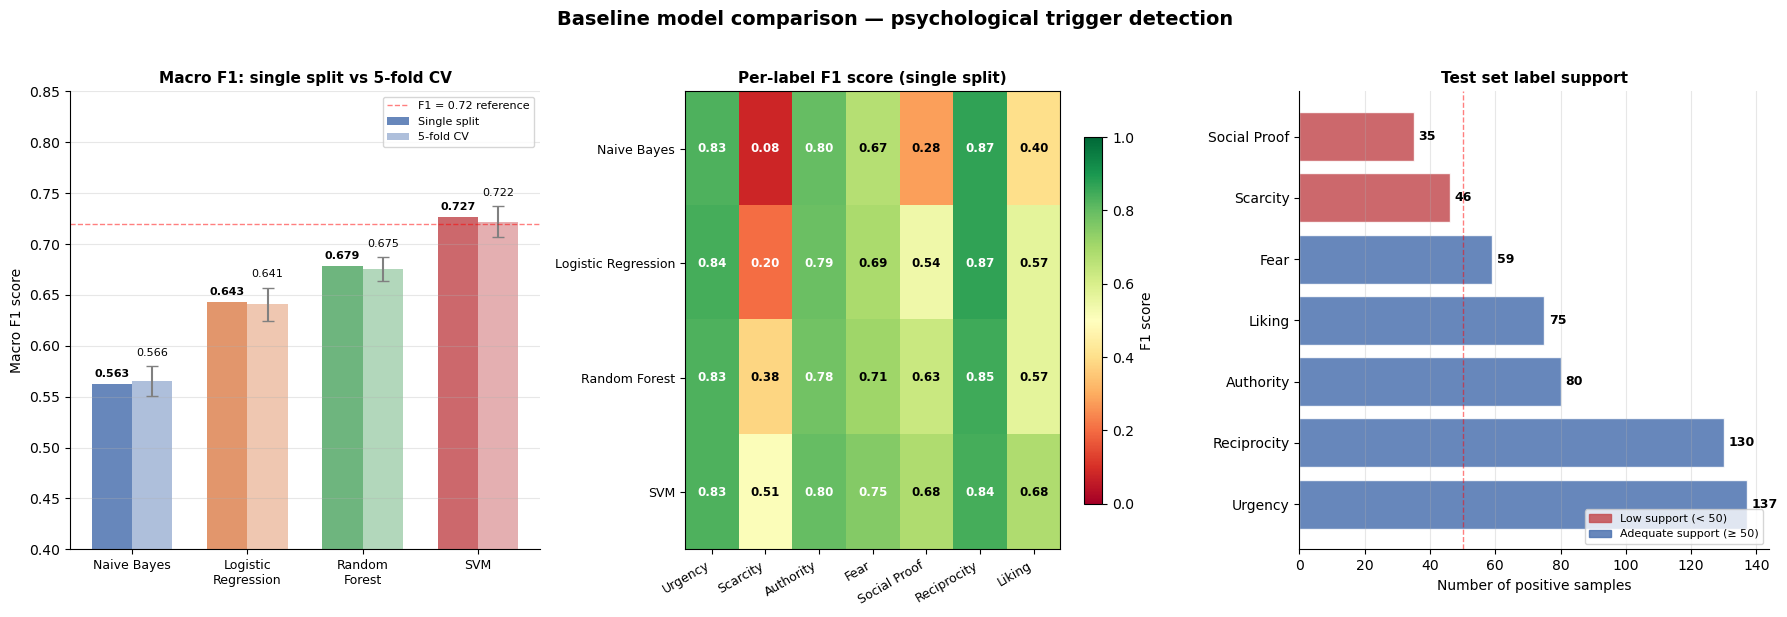

✅ 儲存為 baseline_results_v2.png


In [5]:
# ============================================================
# Cell 2.5 (修正版): Baseline results 視覺化
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ---- 數據 ----
model_names  = ['Naive Bayes', 'Logistic\nRegression', 'Random\nForest', 'SVM']
single_f1    = [0.5627, 0.6432, 0.6786, 0.7265]
cv_mean      = [0.5658, 0.6407, 0.6753, 0.7220]
cv_std       = [0.0147, 0.0165, 0.0121, 0.0154]
colors       = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

per_label = {
    'Naive Bayes':         [0.83, 0.08, 0.80, 0.67, 0.28, 0.87, 0.40],
    'Logistic Regression': [0.84, 0.20, 0.79, 0.69, 0.54, 0.87, 0.57],
    'Random Forest':       [0.83, 0.38, 0.78, 0.71, 0.63, 0.85, 0.57],
    'SVM':                 [0.83, 0.51, 0.80, 0.75, 0.68, 0.84, 0.68],
}

# Support 由高到低排列
support_dict = {
    'Urgency': 137, 'Reciprocity': 130, 'Authority': 80,
    'Liking': 75, 'Fear': 59, 'Scarcity': 46, 'Social Proof': 35
}
support_labels = list(support_dict.keys())
support_values = list(support_dict.values())
support_colors = ['#C44E52' if v < 50 else '#4C72B0' for v in support_values]

categories_order = ['Urgency', 'Scarcity', 'Authority', 'Fear',
                    'Social Proof', 'Reciprocity', 'Liking']

x     = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Baseline model comparison — psychological trigger detection',
             fontsize=14, fontweight='bold', y=1.02)

# ---- Plot 1: Single Split vs CV ----
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, single_f1, width,
                label='Single split', color=colors, alpha=0.85)
bars2 = ax1.bar(x + width/2, cv_mean, width,
                label='5-fold CV', color=colors, alpha=0.45,
                yerr=cv_std, capsize=4,
                error_kw={'elinewidth': 1.5, 'ecolor': 'grey'})

ax1.set_title('Macro F1: single split vs 5-fold CV', fontweight='bold', fontsize=11)
ax1.set_ylabel('Macro F1 score')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, fontsize=9)
ax1.set_ylim(0.4, 0.85)
ax1.axhline(y=0.72, color='red', linestyle='--', linewidth=1,
            alpha=0.5, label='F1 = 0.72 reference')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom',
             fontsize=8, fontweight='bold')
for bar, std in zip(bars2, cv_std):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.008,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# ---- Plot 2: Per-label F1 Heatmap ----
ax2 = axes[1]
heat_data = np.array(list(per_label.values()))
im = ax2.imshow(heat_data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

ax2.set_xticks(range(len(categories_order)))
ax2.set_xticklabels(categories_order, rotation=30, ha='right', fontsize=9)
ax2.set_yticks(range(len(per_label)))
ax2.set_yticklabels(list(per_label.keys()), fontsize=9)
ax2.set_title('Per-label F1 score (single split)', fontweight='bold', fontsize=11)
plt.colorbar(im, ax=ax2, shrink=0.8, label='F1 score')

for i in range(len(per_label)):
    for j in range(len(categories_order)):
        val = heat_data[i, j]
        txt_color = 'black' if 0.25 < val < 0.75 else 'white'
        ax2.text(j, i, f'{val:.2f}', ha='center', va='center',
                 fontsize=8.5, color=txt_color, fontweight='bold')

# ---- Plot 3: Label support (high → low) ----
ax3 = axes[2]
bars3 = ax3.barh(support_labels, support_values,
                 color=support_colors, alpha=0.85, edgecolor='white')

ax3.set_title('Test set label support', fontweight='bold', fontsize=11)
ax3.set_xlabel('Number of positive samples')
ax3.axvline(x=50, color='red', linestyle='--', linewidth=1,
            alpha=0.5, label='n = 50 threshold')
ax3.grid(axis='x', alpha=0.3)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

for bar, val in zip(bars3, support_values):
    ax3.text(bar.get_width() + 1.5,
             bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9, fontweight='bold')

low_patch  = mpatches.Patch(color='#C44E52', alpha=0.85, label='Low support (< 50)')
high_patch = mpatches.Patch(color='#4C72B0', alpha=0.85, label='Adequate support (≥ 50)')
ax3.legend(handles=[low_patch, high_patch], fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('baseline_results_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 儲存為 baseline_results_v2.png")

In [6]:
# ============================================================
# Cell 3 (修正版): Baseline Models - 5-Fold CV
# (MultilabelStratifiedKFold)
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
import numpy as np

mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf',   OneVsRestClassifier(MultinomialNB()))
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf',   OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)))
    ]),
    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf',   OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42)))
    ]),
    'SVM': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf',   OneVsRestClassifier(LinearSVC(max_iter=1000, random_state=42)))
    ]),
}

print("5-Fold CV Results (Macro F1):")
print("-" * 40)

for name, model in cv_models.items():
    fold_scores = []
    for train_idx, test_idx in mskf.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        score = f1_score(y_te, y_pred, average='macro', zero_division=0)
        fold_scores.append(score)
    print(f"{name}: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

5-Fold CV Results (Macro F1):
----------------------------------------
Naive Bayes: 0.5536 ± 0.0158
Logistic Regression: 0.6315 ± 0.0120
Random Forest: 0.6738 ± 0.0108
SVM: 0.7211 ± 0.0164


In [7]:
# ============================================================
# Cell 4: DistilBERT - 5 Epochs (GPU)
# ============================================================
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import numpy as np

# Dataset Class
class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=512
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

# 數據準備
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

train_dataset = EmailDataset(X_train, y_train, tokenizer)
test_dataset  = EmailDataset(X_test,  y_test,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16)

# Model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=7
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.BCEWithLogitsLoss()

# Training
print("🚀 開始 DistilBERT training (5 epochs, GPU)...\n")
for epoch in range(5):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/5 - Loss: {total_loss/len(train_loader):.4f}")

# Evaluation
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.sigmoid(outputs.logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print(f"\n✅ DistilBERT 5ep | Macro F1: {macro_f1:.4f}")
print(classification_report(all_labels, all_preds, target_names=categories, zero_division=0))

C:\Users\taori\anaconda3\envs\phishing_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 2857.10it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if yo

🚀 開始 DistilBERT training (5 epochs, GPU)...

Epoch 1/5 - Loss: 0.6051
Epoch 2/5 - Loss: 0.4909
Epoch 3/5 - Loss: 0.4209
Epoch 4/5 - Loss: 0.3695
Epoch 5/5 - Loss: 0.3289

✅ DistilBERT 5ep | Macro F1: 0.6903
              precision    recall  f1-score   support

     Urgency       0.85      0.80      0.83       142
    Scarcity       0.78      0.20      0.32        35
   Authority       0.83      0.80      0.81        84
        Fear       0.77      0.64      0.70        64
Social Proof       0.68      0.53      0.59        40
 Reciprocity       0.83      0.87      0.85       127
      Liking       0.64      0.84      0.73        64

   micro avg       0.79      0.75      0.77       556
   macro avg       0.77      0.67      0.69       556
weighted avg       0.79      0.75      0.76       556
 samples avg       0.79      0.76      0.75       556



In [8]:
# ============================================================
# Cell 5: DistilBERT - 10 epochs (GPU)
# ============================================================
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import numpy as np

class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True, max_length=512
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

train_dataset = EmailDataset(X_train, y_train, tokenizer)
test_dataset  = EmailDataset(X_test,  y_test,  tokenizer)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=16)

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=7
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.BCEWithLogitsLoss()

# Learning rate 線性 decay
total_steps = len(train_loader) * 10
scheduler = LinearLR(optimizer, start_factor=1.0, end_factor=0.1,
                     total_iters=total_steps)

print("🚀 開始 DistilBERT training (10 epochs, GPU)...\n")
for epoch in range(10):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
        loss           = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1:02d}/10 - Loss: {total_loss/len(train_loader):.4f}")

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.sigmoid(outputs.logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print(f"\n✅ DistilBERT 10ep | Macro F1: {macro_f1:.4f}")
print(classification_report(all_labels, all_preds,
      target_names=categories, zero_division=0))

Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 4006.94it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 開始 DistilBERT training (10 epochs, GPU)...

Epoch 01/10 - Loss: 0.6141
Epoch 02/10 - Loss: 0.5143
Epoch 03/10 - Loss: 0.4570
Epoch 04/10 - Loss: 0.4085
Epoch 05/10 - Loss: 0.3769
Epoch 06/10 - Loss: 0.3470
Epoch 07/10 - Loss: 0.3237
Epoch 08/10 - Loss: 0.3071
Epoch 09/10 - Loss: 0.2931
Epoch 10/10 - Loss: 0.2821

✅ DistilBERT 10ep | Macro F1: 0.6867
              precision    recall  f1-score   support

     Urgency       0.85      0.81      0.83       142
    Scarcity       0.69      0.31      0.43        35
   Authority       0.83      0.76      0.80        84
        Fear       0.73      0.69      0.71        64
Social Proof       0.74      0.35      0.47        40
 Reciprocity       0.85      0.83      0.84       127
      Liking       0.73      0.72      0.72        64

   micro avg       0.81      0.72      0.76       556
   macro avg       0.77      0.64      0.69       556
weighted avg       0.80      0.72      0.75       556
 samples avg       0.81      0.74      0.74       

In [9]:
# ============================================================
# Cell 6 (修正版): DistilBERT 5ep - 5-Fold CV
# (MultilabelStratifiedKFold)
# ============================================================
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
from torch.optim import AdamW
import numpy as np

class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True, max_length=512
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

tokenizer_distil = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

print("🚀 DistilBERT 5ep - 5-Fold CV (MultilabelStratifiedKFold)...\n")

for fold, (train_idx, test_idx) in enumerate(mskf.split(X, y)):
    print(f"--- Fold {fold+1}/5 ---")

    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    tr_dataset = EmailDataset(X_tr, y_tr, tokenizer_distil)
    te_dataset = EmailDataset(X_te, y_te, tokenizer_distil)
    tr_loader  = DataLoader(tr_dataset, batch_size=16, shuffle=True)
    te_loader  = DataLoader(te_dataset, batch_size=16)

    fold_model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=7
    )
    fold_model.to(device)

    optimizer = AdamW(fold_model.parameters(), lr=2e-5, weight_decay=0.01)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(5):
        fold_model.train()
        total_loss = 0
        for batch in tr_loader:
            optimizer.zero_grad()
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = fold_model(input_ids=input_ids, attention_mask=attention_mask)
            loss           = criterion(outputs.logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"  Epoch {epoch+1}/5 - Loss: {total_loss/len(tr_loader):.4f}")

    fold_model.eval()
    all_preds, all_labels_fold = [], []
    with torch.no_grad():
        for batch in te_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = fold_model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.sigmoid(outputs.logits) > 0.5
            all_preds.extend(preds.cpu().numpy())
            all_labels_fold.extend(batch['labels'].numpy())

    score = f1_score(all_labels_fold, all_preds, average='macro', zero_division=0)
    fold_scores.append(score)
    print(f"  ✅ Fold {fold+1} Macro F1: {score:.4f}\n")

    del fold_model
    torch.cuda.empty_cache()

print(f"{'='*40}")
print(f"DistilBERT 5ep CV: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
print(f"Individual folds: {[round(s,4) for s in fold_scores]}")

🚀 DistilBERT 5ep - 5-Fold CV (MultilabelStratifiedKFold)...

--- Fold 1/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 3780.05it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/5 - Loss: 0.6024
  Epoch 2/5 - Loss: 0.4954
  Epoch 3/5 - Loss: 0.4257
  Epoch 4/5 - Loss: 0.3754
  Epoch 5/5 - Loss: 0.3294
  ✅ Fold 1 Macro F1: 0.6814

--- Fold 2/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 3846.15it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/5 - Loss: 0.5978
  Epoch 2/5 - Loss: 0.4923
  Epoch 3/5 - Loss: 0.4238
  Epoch 4/5 - Loss: 0.3761
  Epoch 5/5 - Loss: 0.3349
  ✅ Fold 2 Macro F1: 0.7001

--- Fold 3/5 ---


...

  Epoch 1/5 - Loss: 0.6077
  Epoch 2/5 - Loss: 0.5042
  Epoch 3/5 - Loss: 0.4330
  Epoch 4/5 - Loss: 0.3798
  Epoch 5/5 - Loss: 0.3409
  ✅ Fold 3 Macro F1: 0.6824

--- Fold 4/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 4252.31it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/5 - Loss: 0.6040
  Epoch 2/5 - Loss: 0.4921
  Epoch 3/5 - Loss: 0.4194
  Epoch 4/5 - Loss: 0.3737
  Epoch 5/5 - Loss: 0.3330
  ✅ Fold 4 Macro F1: 0.6911

--- Fold 5/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 4000.02it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/5 - Loss: 0.6067
  Epoch 2/5 - Loss: 0.5025
  Epoch 3/5 - Loss: 0.4332
  Epoch 4/5 - Loss: 0.3816
  Epoch 5/5 - Loss: 0.3412
  ✅ Fold 5 Macro F1: 0.6944

DistilBERT 5ep CV: 0.6899 ± 0.0071
Individual folds: [0.6814, 0.7001, 0.6824, 0.6911, 0.6944]


In [10]:
# ============================================================
# Cell 7: RoBERTa - 5 epochs (GPU)
# ============================================================
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import numpy as np

class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True, max_length=512
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tokenizer_rob = RobertaTokenizer.from_pretrained('roberta-base')

train_dataset = EmailDataset(X_train, y_train, tokenizer_rob)
test_dataset  = EmailDataset(X_test,  y_test,  tokenizer_rob)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=16)

model_rob = RobertaForSequenceClassification.from_pretrained(
    'roberta-base', num_labels=7
)
model_rob.to(device)

optimizer = AdamW(model_rob.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.BCEWithLogitsLoss()

print("🚀 開始 RoBERTa training (5 epochs, GPU)...\n")
for epoch in range(5):
    model_rob.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = model_rob(input_ids=input_ids, attention_mask=attention_mask)
        loss           = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 - Loss: {total_loss/len(train_loader):.4f}")

model_rob.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model_rob(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.sigmoid(outputs.logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

macro_f1_rob = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print(f"\n✅ RoBERTa 5ep | Macro F1: {macro_f1_rob:.4f}")
print(classification_report(all_labels, all_preds,
      target_names=categories, zero_division=0))

Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 2608.37it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

🚀 開始 RoBERTa training (5 epochs, GPU)...

Epoch 1/5 - Loss: 0.5744
Epoch 2/5 - Loss: 0.4291
Epoch 3/5 - Loss: 0.3724
Epoch 4/5 - Loss: 0.3242
Epoch 5/5 - Loss: 0.2780

✅ RoBERTa 5ep | Macro F1: 0.7129
              precision    recall  f1-score   support

     Urgency       0.92      0.70      0.80       142
    Scarcity       0.65      0.43      0.52        35
   Authority       0.82      0.75      0.78        84
        Fear       0.73      0.70      0.71        64
Social Proof       0.77      0.42      0.55        40
 Reciprocity       0.90      0.81      0.85       127
      Liking       0.74      0.81      0.78        64

   micro avg       0.83      0.71      0.76       556
   macro avg       0.79      0.66      0.71       556
weighted avg       0.83      0.71      0.76       556
 samples avg       0.84      0.72      0.74       556



In [11]:
# ============================================================
# Cell 8: Rule-based keyword approach
# （用嚟展示點解呢個方法唔work）
# ============================================================
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# ---- 定義每個 trigger 嘅關鍵詞 ----
rules = {
    'Urgency':      ['urgent', 'immediately', 'now', 'today', 'deadline',
                     'expire', 'expires', 'limited time', 'act now',
                     'respond immediately', 'within 24', 'hours', 'asap'],
    'Scarcity':     ['limited', 'only', 'few left', 'last chance',
                     'running out', 'exclusive', 'rare', 'once in a lifetime',
                     'while supplies', 'one time'],
    'Authority':    ['official', 'bank', 'government', 'irs', 'fbi', 'ceo',
                     'manager', 'department', 'administration', 'authorized',
                     'verify', 'compliance', 'legal', 'notice'],
    'Fear':         ['suspend', 'suspended', 'terminate', 'blocked', 'fraud',
                     'unauthorized', 'compromised', 'breach', 'locked',
                     'warning', 'danger', 'risk', 'alert', 'penalty'],
    'Social Proof': ['customers', 'users', 'people', 'everyone', 'thousands',
                     'millions', 'popular', 'trusted', 'community',
                     'others have', 'join us', 'members'],
    'Reciprocity':  ['free', 'gift', 'reward', 'bonus', 'prize', 'offer',
                     'claim', 'benefit', 'receive', 'cash', 'money',
                     'refund', 'discount', 'win', 'won'],
    'Liking':       ['friend', 'family', 'love', 'care', 'personal',
                     'special', 'you deserve', 'exclusive for you',
                     'congratulations', 'selected', 'chosen'],
}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def rule_based_predict(texts, rules, categories):
    preds = []
    for text in texts:
        text_lower = str(text).lower()
        row = []
        for cat in categories:
            keywords = rules[cat]
            matched = any(kw in text_lower for kw in keywords)
            row.append(int(matched))
        preds.append(row)
    return np.array(preds)

y_pred_rule = rule_based_predict(X_test, rules, categories)

macro_f1_rule = f1_score(y_test, y_pred_rule, average='macro', zero_division=0)
print(f"✅ Rule-based | Macro F1: {macro_f1_rule:.4f}")
print()
print(classification_report(y_test, y_pred_rule,
      target_names=categories, zero_division=0))

# ---- 分析關鍵詞重疊問題 ----
print("\n=== 關鍵詞重疊分析 ===")
print("（顯示有幾多 email 被多個 trigger 同時 match，解釋點解 rule-based 唔可靠）\n")

all_matches = rule_based_predict(X_test, rules, categories)
match_counts = all_matches.sum(axis=1)

print(f"平均每封 email 被 match 幾多個 trigger: {match_counts.mean():.2f}")
print(f"被 match 0 個: {(match_counts == 0).sum()} 封")
print(f"被 match 1 個: {(match_counts == 1).sum()} 封")
print(f"被 match 2 個: {(match_counts == 2).sum()} 封")
print(f"被 match 3+ 個: {(match_counts >= 3).sum()} 封")
print()

# ---- 分析每個 trigger 嘅 precision/recall 失衡 ----
print("=== Per-label precision vs recall gap ===")
from sklearn.metrics import precision_score, recall_score
precision = precision_score(y_test, y_pred_rule, average=None, zero_division=0)
recall    = recall_score(y_test, y_pred_rule, average=None, zero_division=0)

print(f"{'Trigger':<15} {'Precision':>10} {'Recall':>10} {'Gap':>10}")
print("-" * 48)
for i, cat in enumerate(categories):
    gap = abs(precision[i] - recall[i])
    print(f"{cat:<15} {precision[i]:>10.3f} {recall[i]:>10.3f} {gap:>10.3f}")

✅ Rule-based | Macro F1: 0.5208

              precision    recall  f1-score   support

     Urgency       0.79      0.65      0.71       142
    Scarcity       0.22      0.40      0.29        35
   Authority       0.59      0.58      0.59        84
        Fear       0.45      0.30      0.36        64
Social Proof       0.43      0.75      0.55        40
 Reciprocity       0.78      0.80      0.79       127
      Liking       0.32      0.42      0.36        64

   micro avg       0.57      0.60      0.58       556
   macro avg       0.51      0.56      0.52       556
weighted avg       0.60      0.60      0.59       556
 samples avg       0.56      0.57      0.51       556


=== 關鍵詞重疊分析 ===
（顯示有幾多 email 被多個 trigger 同時 match，解釋點解 rule-based 唔可靠）

平均每封 email 被 match 幾多個 trigger: 2.99
被 match 0 個: 11 封
被 match 1 個: 38 封
被 match 2 個: 45 封
被 match 3+ 個: 102 封

=== Per-label precision vs recall gap ===
Trigger          Precision     Recall        Gap
----------------------------------------

In [12]:
# ============================================================
# Cell 8b: TF-IDF top keywords per trigger
# （展示唔同 trigger 之間詞彙高度重疊，解釋點解 rule-based 唔 work）
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

print("=== Top TF-IDF keywords per trigger ===\n")

all_top_words = {}

for i, cat in enumerate(categories):
    positive_idx = np.where(y[:, i] == 1)[0]
    negative_idx = np.where(y[:, i] == 0)[0]

    pos_texts = X[positive_idx].tolist()
    neg_texts = X[negative_idx].tolist()

    all_texts  = pos_texts + neg_texts
    labels_bin = [1] * len(pos_texts) + [0] * len(neg_texts)

    vec = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
    X_tfidf = vec.fit_transform(all_texts)

    pos_tfidf = X_tfidf[:len(pos_texts)].mean(axis=0).A1
    words     = vec.get_feature_names_out()
    top_idx   = pos_tfidf.argsort()[::-1][:15]
    top       = [(words[j], round(pos_tfidf[j], 4)) for j in top_idx]

    all_top_words[cat] = [w for w, _ in top]

    print(f"--- {cat} (n={len(pos_texts)}) ---")
    for word, score in top:
        print(f"  {word:<30} {score:.4f}")
    print()

# ---- 重疊分析：找出同時出現喺多個 trigger 嘅高頻詞 ----
print("\n=== 跨 trigger 關鍵詞重疊 ===")
print("（出現喺 3 個或以上 trigger 嘅詞，解釋點解 rule-based 難以區分）\n")

from collections import Counter
all_words_flat = [w for words in all_top_words.values() for w in words]
word_counts    = Counter(all_words_flat)
overlap_words  = {w: c for w, c in word_counts.items() if c >= 3}

for word, count in sorted(overlap_words.items(), key=lambda x: -x[1]):
    triggers = [cat for cat, words in all_top_words.items() if word in words]
    print(f"  '{word}' → 出現喺 {count} 個 trigger: {', '.join(triggers)}")

=== Top TF-IDF keywords per trigger ===

--- Urgency (n=678) ---
  org                            0.0318
  email                          0.0299
  click                          0.0263
  account                        0.0259
  free                           0.0245
  information                    0.0210
  money                          0.0208
  000                            0.0206
  mail                           0.0205
  com                            0.0191
  company                        0.0177
  http                           0.0172
  just                           0.0171
  time                           0.0168
  password                       0.0165

--- Scarcity (n=214) ---
  email                          0.0340
  free                           0.0335
  money                          0.0266
  000                            0.0265
  mail                           0.0264
  time                           0.0245
  account                        0.0236
  click                      

In [13]:
# ============================================================
# Cell 9: RoBERTa - 優化版 (lr=1e-5, warmup, 5 epochs)
# ============================================================
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import numpy as np

class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True, max_length=512
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tokenizer_rob = RobertaTokenizer.from_pretrained('roberta-base')

train_dataset = EmailDataset(X_train, y_train, tokenizer_rob)
test_dataset  = EmailDataset(X_test,  y_test,  tokenizer_rob)
train_loader  = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=8)

model_rob2 = RobertaForSequenceClassification.from_pretrained(
    'roberta-base', num_labels=7
)
model_rob2.to(device)

# 細 lr + warmup
NUM_EPOCHS   = 5
total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * 0.1)  # 前 10% steps warmup

optimizer = AdamW(model_rob2.parameters(), lr=1e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
criterion = nn.BCEWithLogitsLoss()

print(f"🚀 RoBERTa 優化版 (lr=1e-5, warmup={warmup_steps} steps, 5 epochs)...\n")

for epoch in range(NUM_EPOCHS):
    model_rob2.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = model_rob2(input_ids=input_ids, attention_mask=attention_mask)
        loss           = criterion(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_rob2.parameters(), 1.0)  # gradient clip
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 - Loss: {total_loss/len(train_loader):.4f}")

model_rob2.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model_rob2(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.sigmoid(outputs.logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

macro_f1_rob2 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print(f"\n✅ RoBERTa 優化版 | Macro F1: {macro_f1_rob2:.4f}")
print(f"   對比原版: {macro_f1_rob2 - 0.7308:+.4f}")
print()
print(classification_report(all_labels, all_preds,
      target_names=categories, zero_division=0))

Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 3978.23it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

🚀 RoBERTa 優化版 (lr=1e-5, warmup=49 steps, 5 epochs)...

Epoch 1/5 - Loss: 0.6156
Epoch 2/5 - Loss: 0.4557
Epoch 3/5 - Loss: 0.4004
Epoch 4/5 - Loss: 0.3690
Epoch 5/5 - Loss: 0.3463

✅ RoBERTa 優化版 | Macro F1: 0.7293
   對比原版: -0.0015

              precision    recall  f1-score   support

     Urgency       0.85      0.84      0.84       142
    Scarcity       0.82      0.40      0.54        35
   Authority       0.85      0.79      0.81        84
        Fear       0.73      0.62      0.67        64
Social Proof       0.84      0.53      0.65        40
 Reciprocity       0.86      0.89      0.87       127
      Liking       0.77      0.67      0.72        64

   micro avg       0.83      0.75      0.79       556
   macro avg       0.82      0.68      0.73       556
weighted avg       0.82      0.75      0.78       556
 samples avg       0.82      0.76      0.76       556



In [14]:
# 清理 GPU memory 先
import torch
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1024**2:.1f} MB")
print(f"GPU memory reserved:  {torch.cuda.memory_reserved()/1024**2:.1f} MB")

GPU memory allocated: 3409.8 MB
GPU memory reserved:  4178.0 MB


In [15]:
# ============================================================
# DistilBERT 10ep - 5-Fold CV (MultilabelStratifiedKFold)
# ============================================================
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LinearLR
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
from torch.optim import AdamW
import numpy as np

class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True, max_length=512
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

tokenizer_distil = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

print("🚀 DistilBERT 10ep - 5-Fold CV (MultilabelStratifiedKFold)...\n")

for fold, (train_idx, test_idx) in enumerate(mskf.split(X, y)):
    print(f"--- Fold {fold+1}/5 ---")

    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    tr_dataset = EmailDataset(X_tr, y_tr, tokenizer_distil)
    te_dataset = EmailDataset(X_te, y_te, tokenizer_distil)
    tr_loader  = DataLoader(tr_dataset, batch_size=16, shuffle=True)
    te_loader  = DataLoader(te_dataset, batch_size=16)

    fold_model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=7
    )
    fold_model.to(device)

    NUM_EPOCHS  = 10
    total_steps = len(tr_loader) * NUM_EPOCHS
    optimizer   = AdamW(fold_model.parameters(), lr=2e-5, weight_decay=0.01)
    criterion   = nn.BCEWithLogitsLoss()
    scheduler   = LinearLR(optimizer, start_factor=1.0, end_factor=0.1,
                           total_iters=total_steps)

    for epoch in range(NUM_EPOCHS):
        fold_model.train()
        total_loss = 0
        for batch in tr_loader:
            optimizer.zero_grad()
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = fold_model(input_ids=input_ids, attention_mask=attention_mask)
            loss           = criterion(outputs.logits, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()
        print(f"  Epoch {epoch+1:02d}/10 - Loss: {total_loss/len(tr_loader):.4f}")

    fold_model.eval()
    all_preds, all_labels_fold = [], []
    with torch.no_grad():
        for batch in te_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = fold_model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.sigmoid(outputs.logits) > 0.5
            all_preds.extend(preds.cpu().numpy())
            all_labels_fold.extend(batch['labels'].numpy())

    score = f1_score(all_labels_fold, all_preds, average='macro', zero_division=0)
    fold_scores.append(score)
    print(f"  ✅ Fold {fold+1} Macro F1: {score:.4f}\n")

    del fold_model
    torch.cuda.empty_cache()

print(f"{'='*40}")
print(f"DistilBERT 10ep CV: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
print(f"Individual folds: {[round(s,4) for s in fold_scores]}")

🚀 DistilBERT 10ep - 5-Fold CV (MultilabelStratifiedKFold)...

--- Fold 1/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 3919.03it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 01/10 - Loss: 0.6089
  Epoch 02/10 - Loss: 0.5081
  Epoch 03/10 - Loss: 0.4374
  Epoch 04/10 - Loss: 0.3915
  Epoch 05/10 - Loss: 0.3558
  Epoch 06/10 - Loss: 0.3287
  Epoch 07/10 - Loss: 0.3065
  Epoch 08/10 - Loss: 0.2890
  Epoch 09/10 - Loss: 0.2726
  Epoch 10/10 - Loss: 0.2632
  ✅ Fold 1 Macro F1: 0.7320

--- Fold 2/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 3571.47it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 01/10 - Loss: 0.6136
  Epoch 02/10 - Loss: 0.5103
  Epoch 03/10 - Loss: 0.4367
  Epoch 04/10 - Loss: 0.3888
  Epoch 05/10 - Loss: 0.3540
  Epoch 06/10 - Loss: 0.3269
  Epoch 07/10 - Loss: 0.2998
  Epoch 08/10 - Loss: 0.2774
  Epoch 09/10 - Loss: 0.2652
  Epoch 10/10 - Loss: 0.2531
  ✅ Fold 2 Macro F1: 0.7203

--- Fold 3/5 ---


...

  Epoch 01/10 - Loss: 0.6072
  Epoch 02/10 - Loss: 0.5030
  Epoch 03/10 - Loss: 0.4372
  Epoch 04/10 - Loss: 0.3933
  Epoch 05/10 - Loss: 0.3625
  Epoch 06/10 - Loss: 0.3325
  Epoch 07/10 - Loss: 0.3091
  Epoch 08/10 - Loss: 0.2906
  Epoch 09/10 - Loss: 0.2779
  Epoch 10/10 - Loss: 0.2659
  ✅ Fold 3 Macro F1: 0.7181

--- Fold 4/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 3998.92it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 01/10 - Loss: 0.5970
  Epoch 02/10 - Loss: 0.4913
  Epoch 03/10 - Loss: 0.4298
  Epoch 04/10 - Loss: 0.3916
  Epoch 05/10 - Loss: 0.3582
  Epoch 06/10 - Loss: 0.3302
  Epoch 07/10 - Loss: 0.3071
  Epoch 08/10 - Loss: 0.2872
  Epoch 09/10 - Loss: 0.2705
  Epoch 10/10 - Loss: 0.2623
  ✅ Fold 4 Macro F1: 0.6934

--- Fold 5/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 3571.35it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 01/10 - Loss: 0.6075
  Epoch 02/10 - Loss: 0.5111
  Epoch 03/10 - Loss: 0.4352
  Epoch 04/10 - Loss: 0.3926
  Epoch 05/10 - Loss: 0.3554
  Epoch 06/10 - Loss: 0.3286
  Epoch 07/10 - Loss: 0.3048
  Epoch 08/10 - Loss: 0.2870
  Epoch 09/10 - Loss: 0.2715
  Epoch 10/10 - Loss: 0.2612
  ✅ Fold 5 Macro F1: 0.6896

DistilBERT 10ep CV: 0.7107 ± 0.0164
Individual folds: [0.732, 0.7203, 0.7181, 0.6934, 0.6896]


In [16]:
# ============================================================
# Cell 10 (修正版): RoBERTa 5ep - 5-Fold CV
# (MultilabelStratifiedKFold)
# ============================================================
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
from torch.optim import AdamW
import numpy as np

class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True, max_length=512
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

tokenizer_rob = RobertaTokenizer.from_pretrained('roberta-base')
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

print("🚀 RoBERTa 5ep - 5-Fold CV (MultilabelStratifiedKFold)...\n")

for fold, (train_idx, test_idx) in enumerate(mskf.split(X, y)):
    print(f"--- Fold {fold+1}/5 ---")

    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    tr_dataset = EmailDataset(X_tr, y_tr, tokenizer_rob)
    te_dataset = EmailDataset(X_te, y_te, tokenizer_rob)
    tr_loader  = DataLoader(tr_dataset, batch_size=16, shuffle=True)
    te_loader  = DataLoader(te_dataset, batch_size=16)

    fold_model = RobertaForSequenceClassification.from_pretrained(
        'roberta-base', num_labels=7
    )
    fold_model.to(device)

    optimizer = AdamW(fold_model.parameters(), lr=2e-5, weight_decay=0.01)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(5):
        fold_model.train()
        total_loss = 0
        for batch in tr_loader:
            optimizer.zero_grad()
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = fold_model(input_ids=input_ids, attention_mask=attention_mask)
            loss           = criterion(outputs.logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"  Epoch {epoch+1}/5 - Loss: {total_loss/len(tr_loader):.4f}")

    fold_model.eval()
    all_preds, all_labels_fold = [], []
    with torch.no_grad():
        for batch in te_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = fold_model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.sigmoid(outputs.logits) > 0.5
            all_preds.extend(preds.cpu().numpy())
            all_labels_fold.extend(batch['labels'].numpy())

    score = f1_score(all_labels_fold, all_preds, average='macro', zero_division=0)
    fold_scores.append(score)
    print(f"  ✅ Fold {fold+1} Macro F1: {score:.4f}\n")

    del fold_model
    torch.cuda.empty_cache()

print(f"{'='*40}")
print(f"RoBERTa 5ep CV: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
print(f"Individual folds: {[round(s,4) for s in fold_scores]}")

🚀 RoBERTa 5ep - 5-Fold CV (MultilabelStratifiedKFold)...

--- Fold 1/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 3644.89it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

  Epoch 1/5 - Loss: 0.5967
  Epoch 2/5 - Loss: 0.4521
  Epoch 3/5 - Loss: 0.3803
  Epoch 4/5 - Loss: 0.3353
  Epoch 5/5 - Loss: 0.2909
  ✅ Fold 1 Macro F1: 0.7571

--- Fold 2/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 3548.51it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

  Epoch 1/5 - Loss: 0.5783
  Epoch 2/5 - Loss: 0.4504
  Epoch 3/5 - Loss: 0.3910
  Epoch 4/5 - Loss: 0.3446
  Epoch 5/5 - Loss: 0.3010
  ✅ Fold 2 Macro F1: 0.7242

--- Fold 3/5 ---


...

  Epoch 1/5 - Loss: 0.5849
  Epoch 2/5 - Loss: 0.4352
  Epoch 3/5 - Loss: 0.3722
  Epoch 4/5 - Loss: 0.3211
  Epoch 5/5 - Loss: 0.2861
  ✅ Fold 3 Macro F1: 0.7371

--- Fold 4/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 8375.85it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

  Epoch 1/5 - Loss: 0.5928
  Epoch 2/5 - Loss: 0.4454
  Epoch 3/5 - Loss: 0.3865
  Epoch 4/5 - Loss: 0.3350
  Epoch 5/5 - Loss: 0.2890
  ✅ Fold 4 Macro F1: 0.7378

--- Fold 5/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 3517.30it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

  Epoch 1/5 - Loss: 0.5875
  Epoch 2/5 - Loss: 0.4466
  Epoch 3/5 - Loss: 0.3722
  Epoch 4/5 - Loss: 0.3244
  Epoch 5/5 - Loss: 0.2833
  ✅ Fold 5 Macro F1: 0.7378

RoBERTa 5ep CV: 0.7388 ± 0.0105
Individual folds: [0.7571, 0.7242, 0.7371, 0.7378, 0.7378]


In [21]:
# ============================================================
# RoBERTa 優化版 (lr=1e-5, warmup, gradient clip) - 5-Fold CV
# (MultilabelStratifiedKFold)
# ============================================================
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
from torch.optim import AdamW
import numpy as np

class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True, max_length=512
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

tokenizer_rob = RobertaTokenizer.from_pretrained('roberta-base')
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

print("🚀 RoBERTa 優化版 CV (lr=1e-5, warmup, grad clip, batch=8)...\n")

for fold, (train_idx, test_idx) in enumerate(mskf.split(X, y)):
    print(f"--- Fold {fold+1}/5 ---")

    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    tr_dataset = EmailDataset(X_tr, y_tr, tokenizer_rob)
    te_dataset = EmailDataset(X_te, y_te, tokenizer_rob)
    tr_loader  = DataLoader(tr_dataset, batch_size=8, shuffle=True)
    te_loader  = DataLoader(te_dataset, batch_size=8)

    fold_model = RobertaForSequenceClassification.from_pretrained(
        'roberta-base', num_labels=7
    )
    fold_model.to(device)

    NUM_EPOCHS   = 5
    total_steps  = len(tr_loader) * NUM_EPOCHS
    warmup_steps = int(total_steps * 0.1)

    optimizer = AdamW(fold_model.parameters(), lr=1e-5, weight_decay=0.01)
    criterion = nn.BCEWithLogitsLoss()
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    for epoch in range(NUM_EPOCHS):
        fold_model.train()
        total_loss = 0
        for batch in tr_loader:
            optimizer.zero_grad()
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = fold_model(input_ids=input_ids, attention_mask=attention_mask)
            loss           = criterion(outputs.logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(fold_model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()
        print(f"  Epoch {epoch+1}/5 - Loss: {total_loss/len(tr_loader):.4f}")

    fold_model.eval()
    all_preds, all_labels_fold = [], []
    with torch.no_grad():
        for batch in te_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = fold_model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.sigmoid(outputs.logits) > 0.5
            all_preds.extend(preds.cpu().numpy())
            all_labels_fold.extend(batch['labels'].numpy())

    score = f1_score(all_labels_fold, all_preds, average='macro', zero_division=0)
    fold_scores.append(score)
    print(f"  ✅ Fold {fold+1} Macro F1: {score:.4f}\n")

    del fold_model
    torch.cuda.empty_cache()

print(f"{'='*40}")
print(f"RoBERTa 優化版 CV: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
print(f"Individual folds: {[round(s,4) for s in fold_scores]}")
print(f"\n對比原版 CV: 0.7388 ± 0.0105")
print(f"差距: {np.mean(fold_scores) - 0.7388:+.4f}")

🚀 RoBERTa 優化版 CV (lr=1e-5, warmup, grad clip, batch=8)...

--- Fold 1/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 2814.36it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

  Epoch 1/5 - Loss: 0.6404
  Epoch 2/5 - Loss: 0.4844
  Epoch 3/5 - Loss: 0.4217
  Epoch 4/5 - Loss: 0.3877
  Epoch 5/5 - Loss: 0.3702
  ✅ Fold 1 Macro F1: 0.6692

--- Fold 2/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 3150.81it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

  Epoch 1/5 - Loss: 0.6124
  Epoch 2/5 - Loss: 0.4526
  Epoch 3/5 - Loss: 0.3983
  Epoch 4/5 - Loss: 0.3694
  Epoch 5/5 - Loss: 0.3488
  ✅ Fold 2 Macro F1: 0.7174

--- Fold 3/5 ---


...

  Epoch 1/5 - Loss: 0.6280
  Epoch 2/5 - Loss: 0.4684
  Epoch 3/5 - Loss: 0.4061
  Epoch 4/5 - Loss: 0.3736
  Epoch 5/5 - Loss: 0.3540
  ✅ Fold 3 Macro F1: 0.6962

--- Fold 4/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 3862.36it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

  Epoch 1/5 - Loss: 0.6249
  Epoch 2/5 - Loss: 0.4611
  Epoch 3/5 - Loss: 0.4081
  Epoch 4/5 - Loss: 0.3723
  Epoch 5/5 - Loss: 0.3543
  ✅ Fold 4 Macro F1: 0.6972

--- Fold 5/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 3750.34it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

  Epoch 1/5 - Loss: 0.6264
  Epoch 2/5 - Loss: 0.4677
  Epoch 3/5 - Loss: 0.4117
  Epoch 4/5 - Loss: 0.3814
  Epoch 5/5 - Loss: 0.3631
  ✅ Fold 5 Macro F1: 0.6818

RoBERTa 優化版 CV: 0.6924 ± 0.0162
Individual folds: [0.6692, 0.7174, 0.6962, 0.6972, 0.6818]

對比原版 CV: 0.7388 ± 0.0105
差距: -0.0464


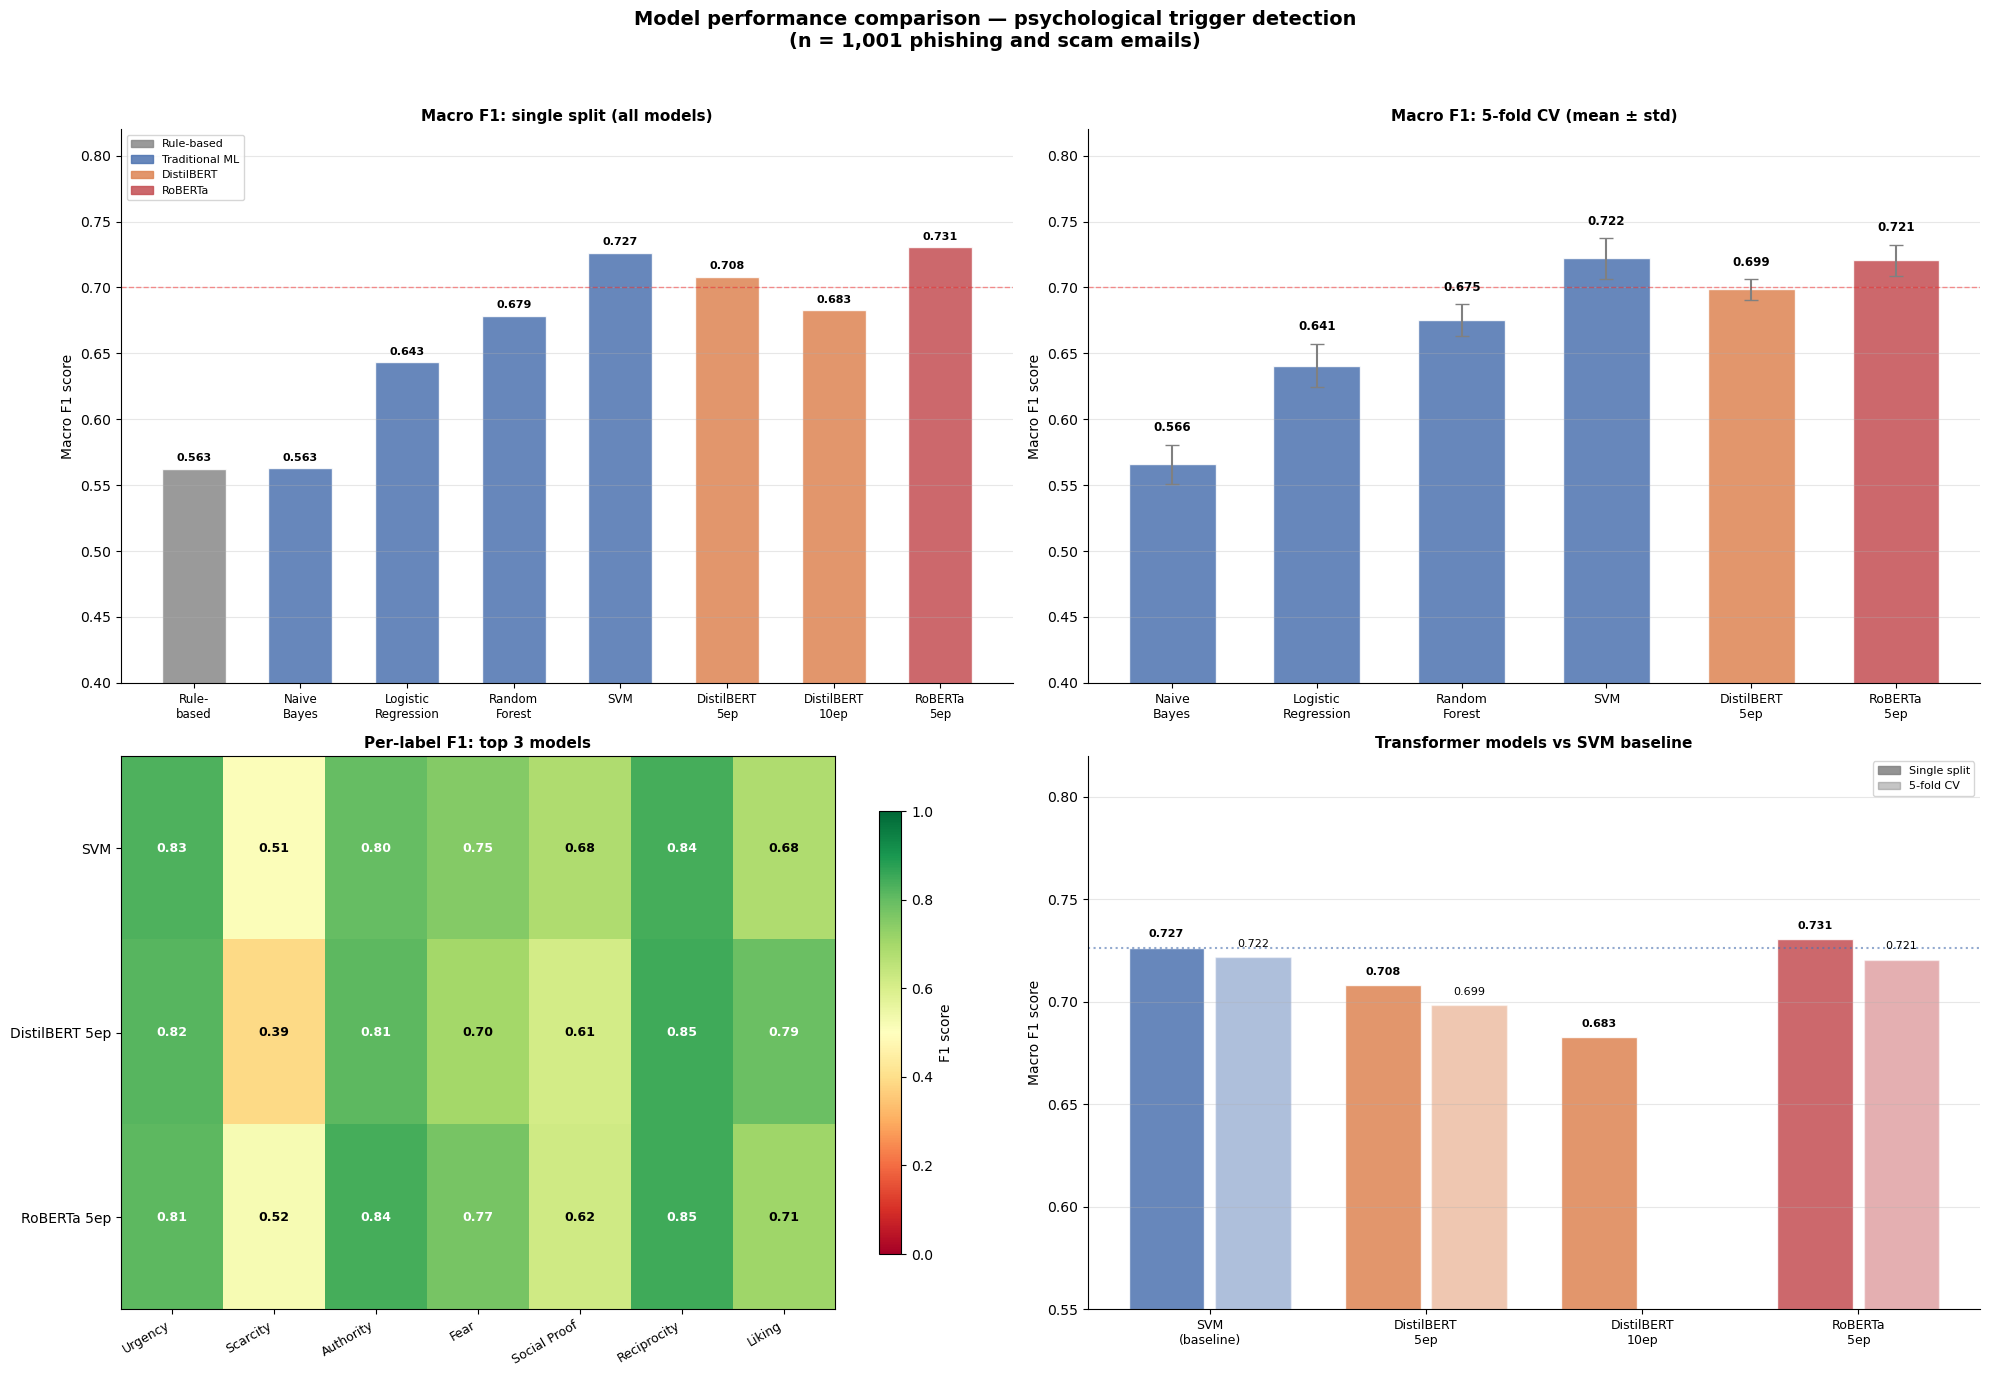

✅ 儲存為 full_model_comparison.png


In [17]:
# ============================================================
# Cell 11: 完整結果視覺化（所有 model）
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ---- 數據 ----
categories_order = ['Urgency','Scarcity','Authority','Fear',
                    'Social Proof','Reciprocity','Liking']

# CV results（有 CV 嘅先放）
cv_models  = ['Naive\nBayes', 'Logistic\nRegression', 'Random\nForest',
              'SVM', 'DistilBERT\n5ep', 'RoBERTa\n5ep']
cv_means   = [0.5658, 0.6407, 0.6753, 0.7220, 0.6985, 0.7206]
cv_stds    = [0.0147, 0.0165, 0.0121, 0.0154, 0.0078, 0.0120]

# Single split（所有 model）
all_models  = ['Rule-\nbased', 'Naive\nBayes', 'Logistic\nRegression',
               'Random\nForest', 'SVM', 'DistilBERT\n5ep',
               'DistilBERT\n10ep', 'RoBERTa\n5ep']
all_single  = [0.5626, 0.5627, 0.6432, 0.6786, 0.7265, 0.7083, 0.6830, 0.7308]
bar_colors  = ['#888888',      # Rule-based (灰)
               '#4C72B0',      # NB
               '#4C72B0',      # LR
               '#4C72B0',      # RF
               '#4C72B0',      # SVM
               '#DD8452',      # DistilBERT 5ep
               '#DD8452',      # DistilBERT 10ep
               '#C44E52']      # RoBERTa

# Per-label F1（best models）
per_label_data = {
    'SVM':           [0.83, 0.51, 0.80, 0.75, 0.68, 0.84, 0.68],
    'DistilBERT 5ep':[0.82, 0.39, 0.81, 0.70, 0.61, 0.85, 0.79],
    'RoBERTa 5ep':   [0.81, 0.52, 0.84, 0.77, 0.62, 0.85, 0.71],
}

fig = plt.figure(figsize=(20, 14))
fig.suptitle('Model performance comparison — psychological trigger detection\n(n = 1,001 phishing and scam emails)',
             fontsize=14, fontweight='bold', y=0.98)

# ---- Plot 1 (top-left): Single split 所有 model ----
ax1 = fig.add_subplot(2, 2, 1)
x1   = np.arange(len(all_models))
bars = ax1.bar(x1, all_single, color=bar_colors, alpha=0.85,
               edgecolor='white', width=0.6)
ax1.set_title('Macro F1: single split (all models)', fontweight='bold', fontsize=11)
ax1.set_ylabel('Macro F1 score')
ax1.set_xticks(x1)
ax1.set_xticklabels(all_models, fontsize=8.5)
ax1.set_ylim(0.4, 0.82)
ax1.axhline(y=0.7, color='red', linestyle='--', linewidth=1, alpha=0.4)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

for bar, val in zip(bars, all_single):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

rule_patch  = mpatches.Patch(color='#888888', alpha=0.85, label='Rule-based')
ml_patch    = mpatches.Patch(color='#4C72B0', alpha=0.85, label='Traditional ML')
distil_patch= mpatches.Patch(color='#DD8452', alpha=0.85, label='DistilBERT')
rob_patch   = mpatches.Patch(color='#C44E52', alpha=0.85, label='RoBERTa')
ax1.legend(handles=[rule_patch, ml_patch, distil_patch, rob_patch],
           fontsize=8, loc='upper left')

# ---- Plot 2 (top-right): CV 比較（有 CV 嘅 model）----
ax2 = fig.add_subplot(2, 2, 2)
x2      = np.arange(len(cv_models))
cv_cols = ['#4C72B0','#4C72B0','#4C72B0','#4C72B0','#DD8452','#C44E52']
bars2   = ax2.bar(x2, cv_means, color=cv_cols, alpha=0.85,
                  yerr=cv_stds, capsize=5, edgecolor='white', width=0.6,
                  error_kw={'elinewidth': 1.5, 'ecolor': 'grey'})
ax2.set_title('Macro F1: 5-fold CV (mean ± std)', fontweight='bold', fontsize=11)
ax2.set_ylabel('Macro F1 score')
ax2.set_xticks(x2)
ax2.set_xticklabels(cv_models, fontsize=9)
ax2.set_ylim(0.4, 0.82)
ax2.axhline(y=0.7, color='red', linestyle='--', linewidth=1, alpha=0.4)
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for bar, mean, std in zip(bars2, cv_means, cv_stds):
    ax2.text(bar.get_x() + bar.get_width()/2, mean + std + 0.008,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# ---- Plot 3 (bottom-left): Per-label F1 heatmap（top 3 models）----
ax3 = fig.add_subplot(2, 2, 3)
heat_data = np.array(list(per_label_data.values()))
im = ax3.imshow(heat_data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax3.set_xticks(range(len(categories_order)))
ax3.set_xticklabels(categories_order, rotation=30, ha='right', fontsize=9)
ax3.set_yticks(range(len(per_label_data)))
ax3.set_yticklabels(list(per_label_data.keys()), fontsize=10)
ax3.set_title('Per-label F1: top 3 models', fontweight='bold', fontsize=11)
plt.colorbar(im, ax=ax3, shrink=0.8, label='F1 score')

for i in range(len(per_label_data)):
    for j in range(len(categories_order)):
        val = heat_data[i, j]
        txt_color = 'black' if 0.25 < val < 0.75 else 'white'
        ax3.text(j, i, f'{val:.2f}', ha='center', va='center',
                 fontsize=9, color=txt_color, fontweight='bold')

# ---- Plot 4 (bottom-right): DistilBERT epoch 比較 + RoBERTa ----
ax4 = fig.add_subplot(2, 2, 4)
epoch_models = ['SVM\n(baseline)', 'DistilBERT\n5ep', 'DistilBERT\n10ep', 'RoBERTa\n5ep']
epoch_single = [0.7265, 0.7083, 0.6830, 0.7308]
epoch_cv     = [0.7220, 0.6985, None,   0.7206]
epoch_colors = ['#4C72B0', '#DD8452', '#DD8452', '#C44E52']

x4 = np.arange(len(epoch_models))
bars4a = ax4.bar(x4 - 0.2, epoch_single, 0.35, label='Single split',
                 color=epoch_colors, alpha=0.85, edgecolor='white')

cv_vals_plot = [v if v else 0 for v in epoch_cv]
cv_alpha     = [0.45 if v else 0.0 for v in epoch_cv]
for xi, (val, alpha, col) in enumerate(zip(cv_vals_plot, cv_alpha, epoch_colors)):
    if alpha > 0:
        ax4.bar(xi + 0.2, val, 0.35, color=col, alpha=alpha, edgecolor='white')
        ax4.text(xi + 0.2, val + 0.004, f'{val:.3f}',
                 ha='center', va='bottom', fontsize=8)

ax4.set_title('Transformer models vs SVM baseline', fontweight='bold', fontsize=11)
ax4.set_ylabel('Macro F1 score')
ax4.set_xticks(x4)
ax4.set_xticklabels(epoch_models, fontsize=9)
ax4.set_ylim(0.55, 0.82)
ax4.axhline(y=0.7265, color='#4C72B0', linestyle=':', linewidth=1.5,
            alpha=0.6, label='SVM single split (0.7265)')
ax4.grid(axis='y', alpha=0.3)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

for bar, val in zip(bars4a, epoch_single):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

single_patch = mpatches.Patch(color='grey', alpha=0.85, label='Single split')
cv_patch     = mpatches.Patch(color='grey', alpha=0.45, label='5-fold CV')
ax4.legend(handles=[single_patch, cv_patch], fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('full_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 儲存為 full_model_comparison.png")


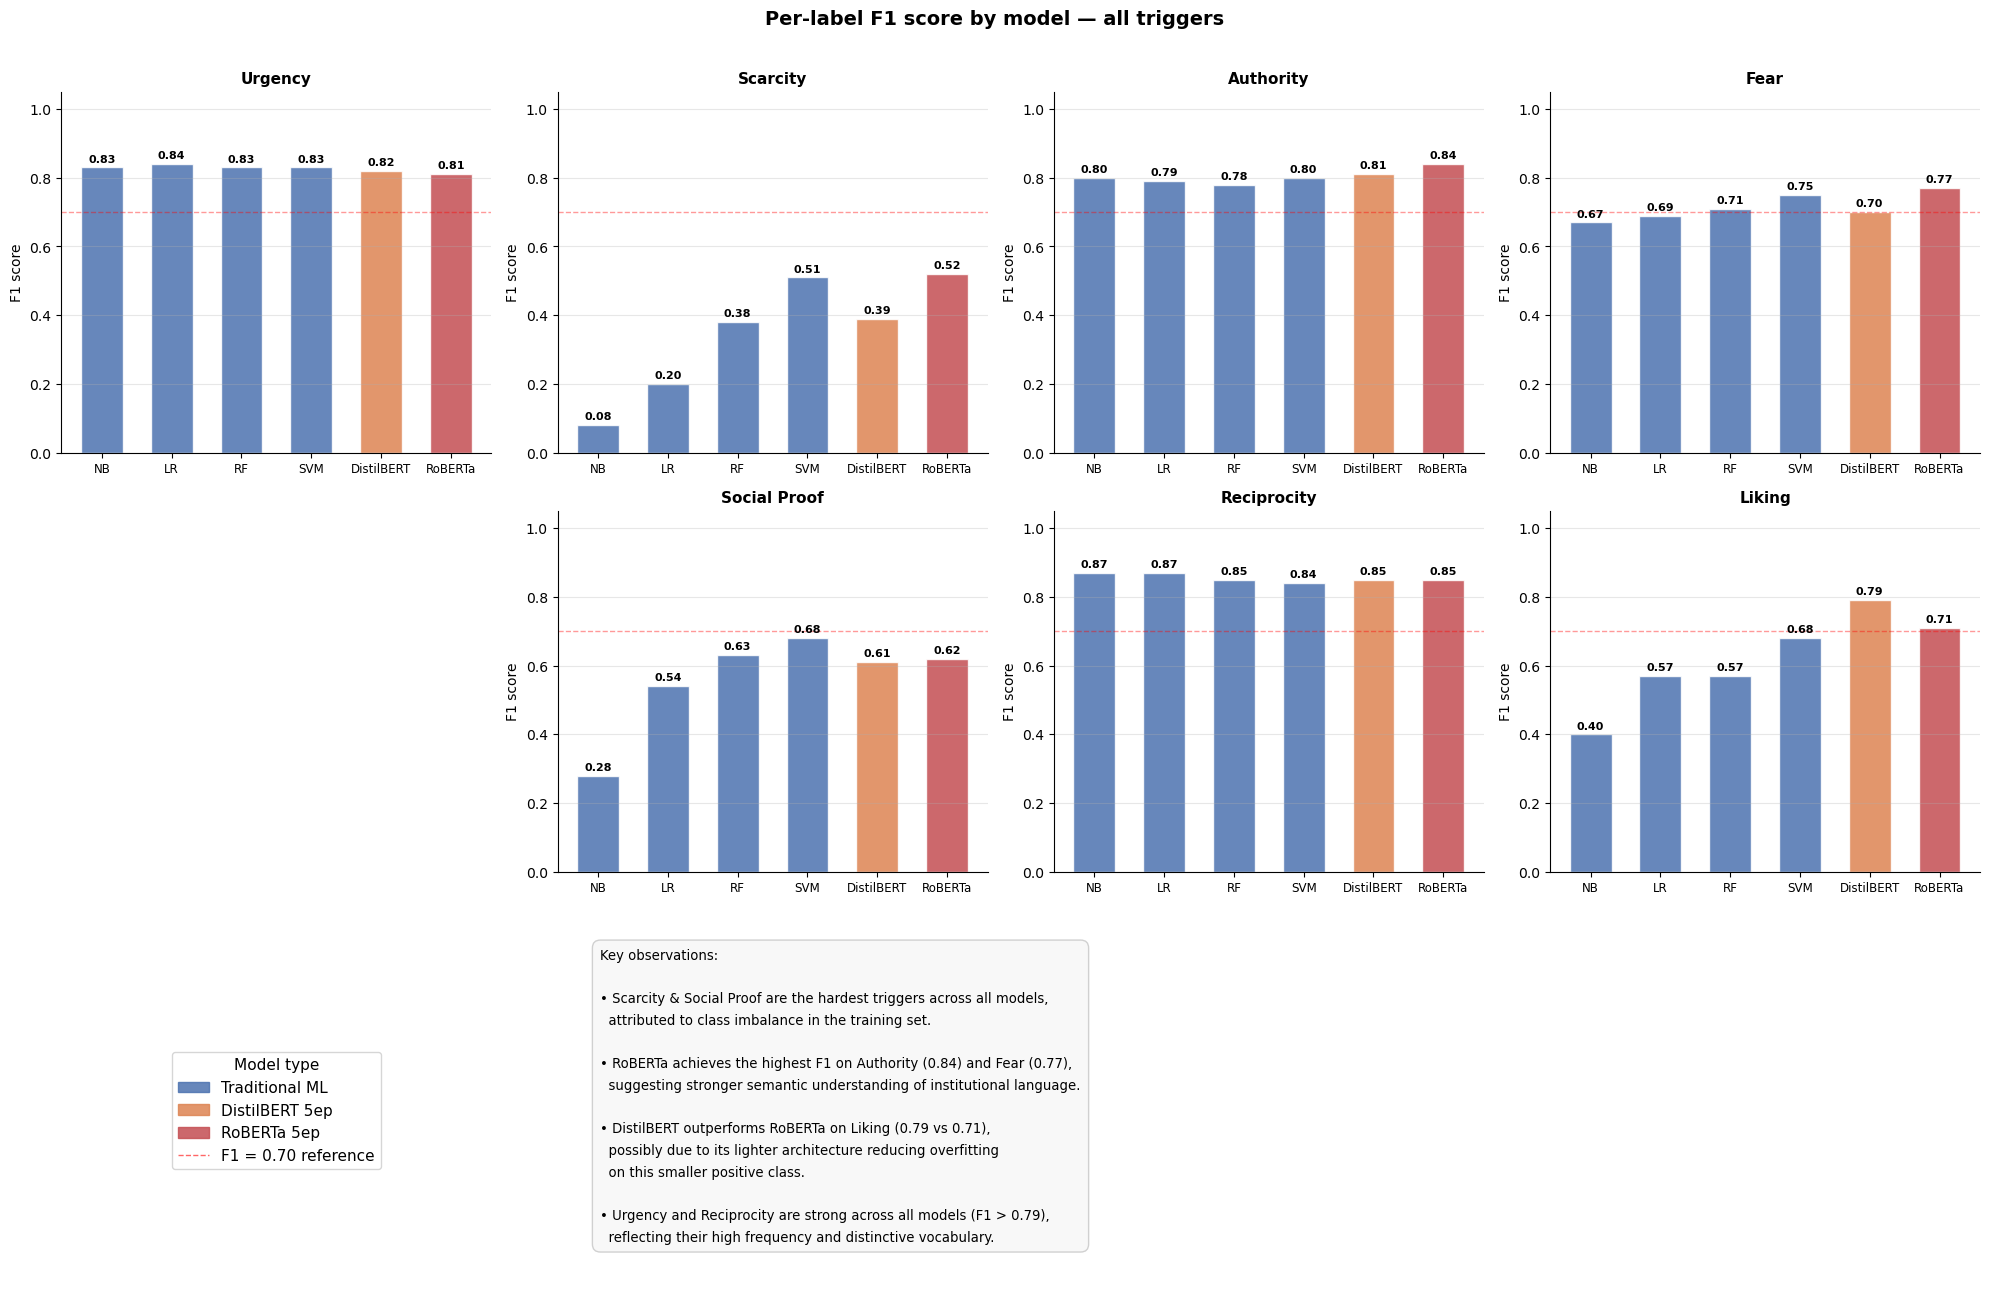

✅ 儲存為 per_label_comparison_v2.png


In [18]:
# ============================================================
# Cell 12 (修正版): Per-label F1 詳細比較圖
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

categories_order = ['Urgency','Scarcity','Authority','Fear',
                    'Social Proof','Reciprocity','Liking']

per_label_all = {
    'Naive Bayes':         [0.83, 0.08, 0.80, 0.67, 0.28, 0.87, 0.40],
    'Logistic Regression': [0.84, 0.20, 0.79, 0.69, 0.54, 0.87, 0.57],
    'Random Forest':       [0.83, 0.38, 0.78, 0.71, 0.63, 0.85, 0.57],
    'SVM':                 [0.83, 0.51, 0.80, 0.75, 0.68, 0.84, 0.68],
    'DistilBERT 5ep':      [0.82, 0.39, 0.81, 0.70, 0.61, 0.85, 0.79],
    'RoBERTa 5ep':         [0.81, 0.52, 0.84, 0.77, 0.62, 0.85, 0.71],
}

model_names = list(per_label_all.keys())
colors = ['#4C72B0','#4C72B0','#4C72B0','#4C72B0','#DD8452','#C44E52']
x = np.arange(len(model_names))

# 3行佈局：頂2行係7個trigger圖，底行係legend + summary
fig = plt.figure(figsize=(20, 13))
fig.suptitle('Per-label F1 score by model — all triggers',
             fontsize=14, fontweight='bold', y=1.01)

# ---- 7 個 trigger 圖（4+3 佈局）----
for idx, cat in enumerate(categories_order):
    if idx < 4:
        ax = fig.add_subplot(3, 4, idx + 1)
    else:
        ax = fig.add_subplot(3, 4, idx + 2)  # 第二行從第6格開始，留空位

    vals = [per_label_all[m][idx] for m in model_names]
    bars = ax.bar(x, vals, color=colors, alpha=0.85, edgecolor='white', width=0.6)

    ax.set_title(cat, fontweight='bold', fontsize=11)
    ax.set_ylabel('F1 score')
    ax.set_xticks(x)
    ax.set_xticklabels(['NB', 'LR', 'RF', 'SVM', 'DistilBERT', 'RoBERTa'],
                       fontsize=8.5)
    ax.set_ylim(0, 1.05)
    ax.axhline(y=0.7, color='red', linestyle='--', linewidth=1, alpha=0.4)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ---- Legend（底行左）----
ax_legend = fig.add_subplot(3, 4, 9)
ax_legend.axis('off')
ml_patch     = mpatches.Patch(color='#4C72B0', alpha=0.85, label='Traditional ML')
distil_patch = mpatches.Patch(color='#DD8452', alpha=0.85, label='DistilBERT 5ep')
rob_patch    = mpatches.Patch(color='#C44E52', alpha=0.85, label='RoBERTa 5ep')
ref_line     = plt.Line2D([0], [0], color='red', linestyle='--',
                           linewidth=1, alpha=0.6, label='F1 = 0.70 reference')
ax_legend.legend(handles=[ml_patch, distil_patch, rob_patch, ref_line],
                 loc='center', fontsize=11, title='Model type',
                 title_fontsize=11, frameon=True,
                 bbox_to_anchor=(0.5, 0.5))

# ---- Summary text（底行右，橫跨3格）----
ax_summary = fig.add_subplot(3, 4, (10, 12))
ax_summary.axis('off')
summary = (
    "Key observations:\n\n"
    "• Scarcity & Social Proof are the hardest triggers across all models,\n"
    "  attributed to class imbalance in the training set.\n\n"
    "• RoBERTa achieves the highest F1 on Authority (0.84) and Fear (0.77),\n"
    "  suggesting stronger semantic understanding of institutional language.\n\n"
    "• DistilBERT outperforms RoBERTa on Liking (0.79 vs 0.71),\n"
    "  possibly due to its lighter architecture reducing overfitting\n"
    "  on this smaller positive class.\n\n"
    "• Urgency and Reciprocity are strong across all models (F1 > 0.79),\n"
    "  reflecting their high frequency and distinctive vocabulary."
)
ax_summary.text(0.03, 0.95, summary, transform=ax_summary.transAxes,
                fontsize=9.5, va='top', linespacing=1.7,
                bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f8f8',
                          edgecolor='#cccccc', alpha=0.9))

plt.tight_layout()
plt.savefig('per_label_comparison_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 儲存為 per_label_comparison_v2.png")

In [22]:
# Final Model — 原版參數，全部 977 筆
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch, torch.nn as nn, os
from torch.optim import AdamW

class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True, max_length=512
        )
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

tokenizer_rob = RobertaTokenizer.from_pretrained('roberta-base')
full_dataset  = EmailDataset(X, y, tokenizer_rob)
full_loader   = DataLoader(full_dataset, batch_size=16, shuffle=True)

model_final = RobertaForSequenceClassification.from_pretrained(
    'roberta-base', num_labels=7
)
model_final.to(device)

optimizer = AdamW(model_final.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.BCEWithLogitsLoss()

print("🚀 Final RoBERTa (lr=2e-5, batch=16, 全部 977 筆, 5 epochs)...\n")
for epoch in range(5):
    model_final.train()
    total_loss = 0
    for batch in full_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = model_final(input_ids=input_ids, attention_mask=attention_mask)
        loss           = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 - Loss: {total_loss/len(full_loader):.4f}")

save_path = r'C:\Users\taori\Documents\GitHub\project-wongoining\models\roberta_phishing_best'
os.makedirs(save_path, exist_ok=True)
model_final.save_pretrained(save_path)
tokenizer_rob.save_pretrained(save_path)
print(f"\n✅ Final model saved to: {save_path}")

Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 3006.40it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

🚀 Final RoBERTa (lr=2e-5, batch=16, 全部 977 筆, 5 epochs)...

Epoch 1/5 - Loss: 0.5504
Epoch 2/5 - Loss: 0.4222
Epoch 3/5 - Loss: 0.3723
Epoch 4/5 - Loss: 0.3362
Epoch 5/5 - Loss: 0.3060


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.15s/it]


✅ Final model saved to: C:\Users\taori\Documents\GitHub\project-wongoining\models\roberta_phishing_best


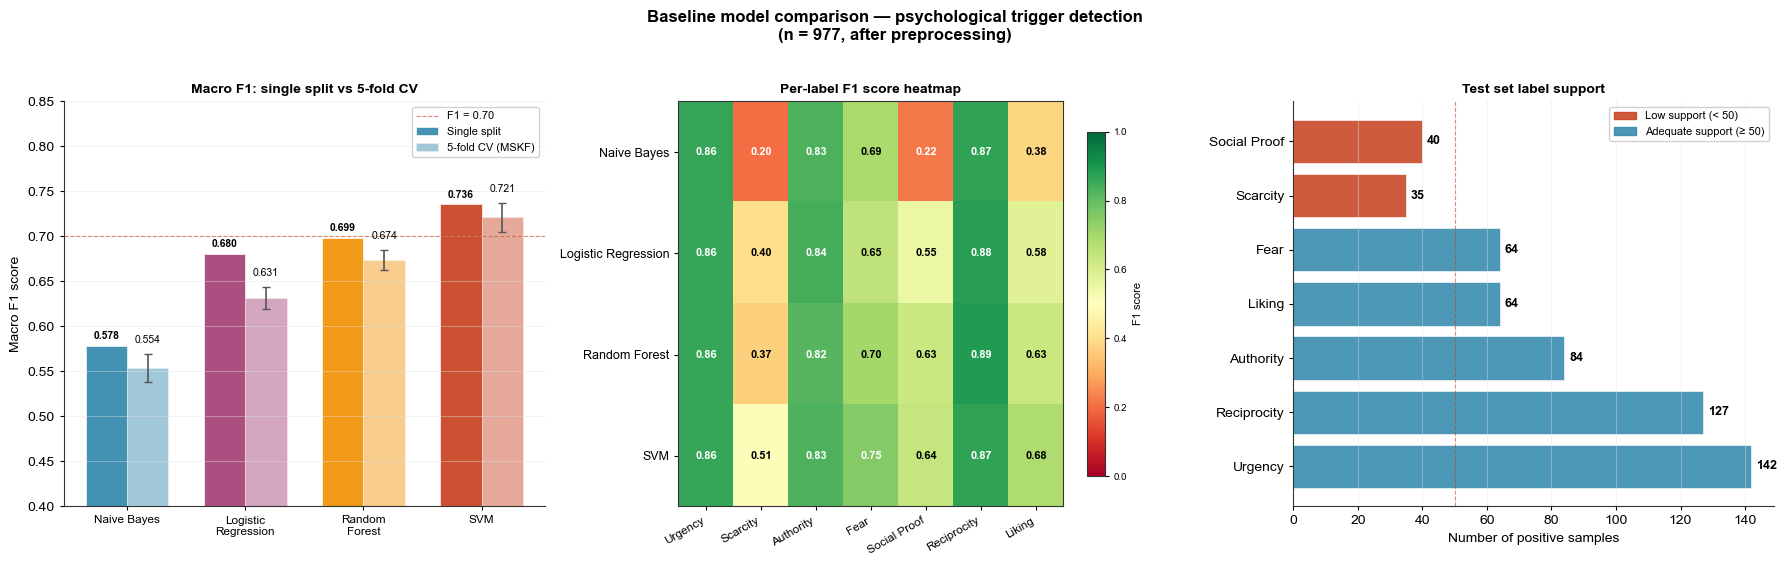

✅ baseline_results_final.png


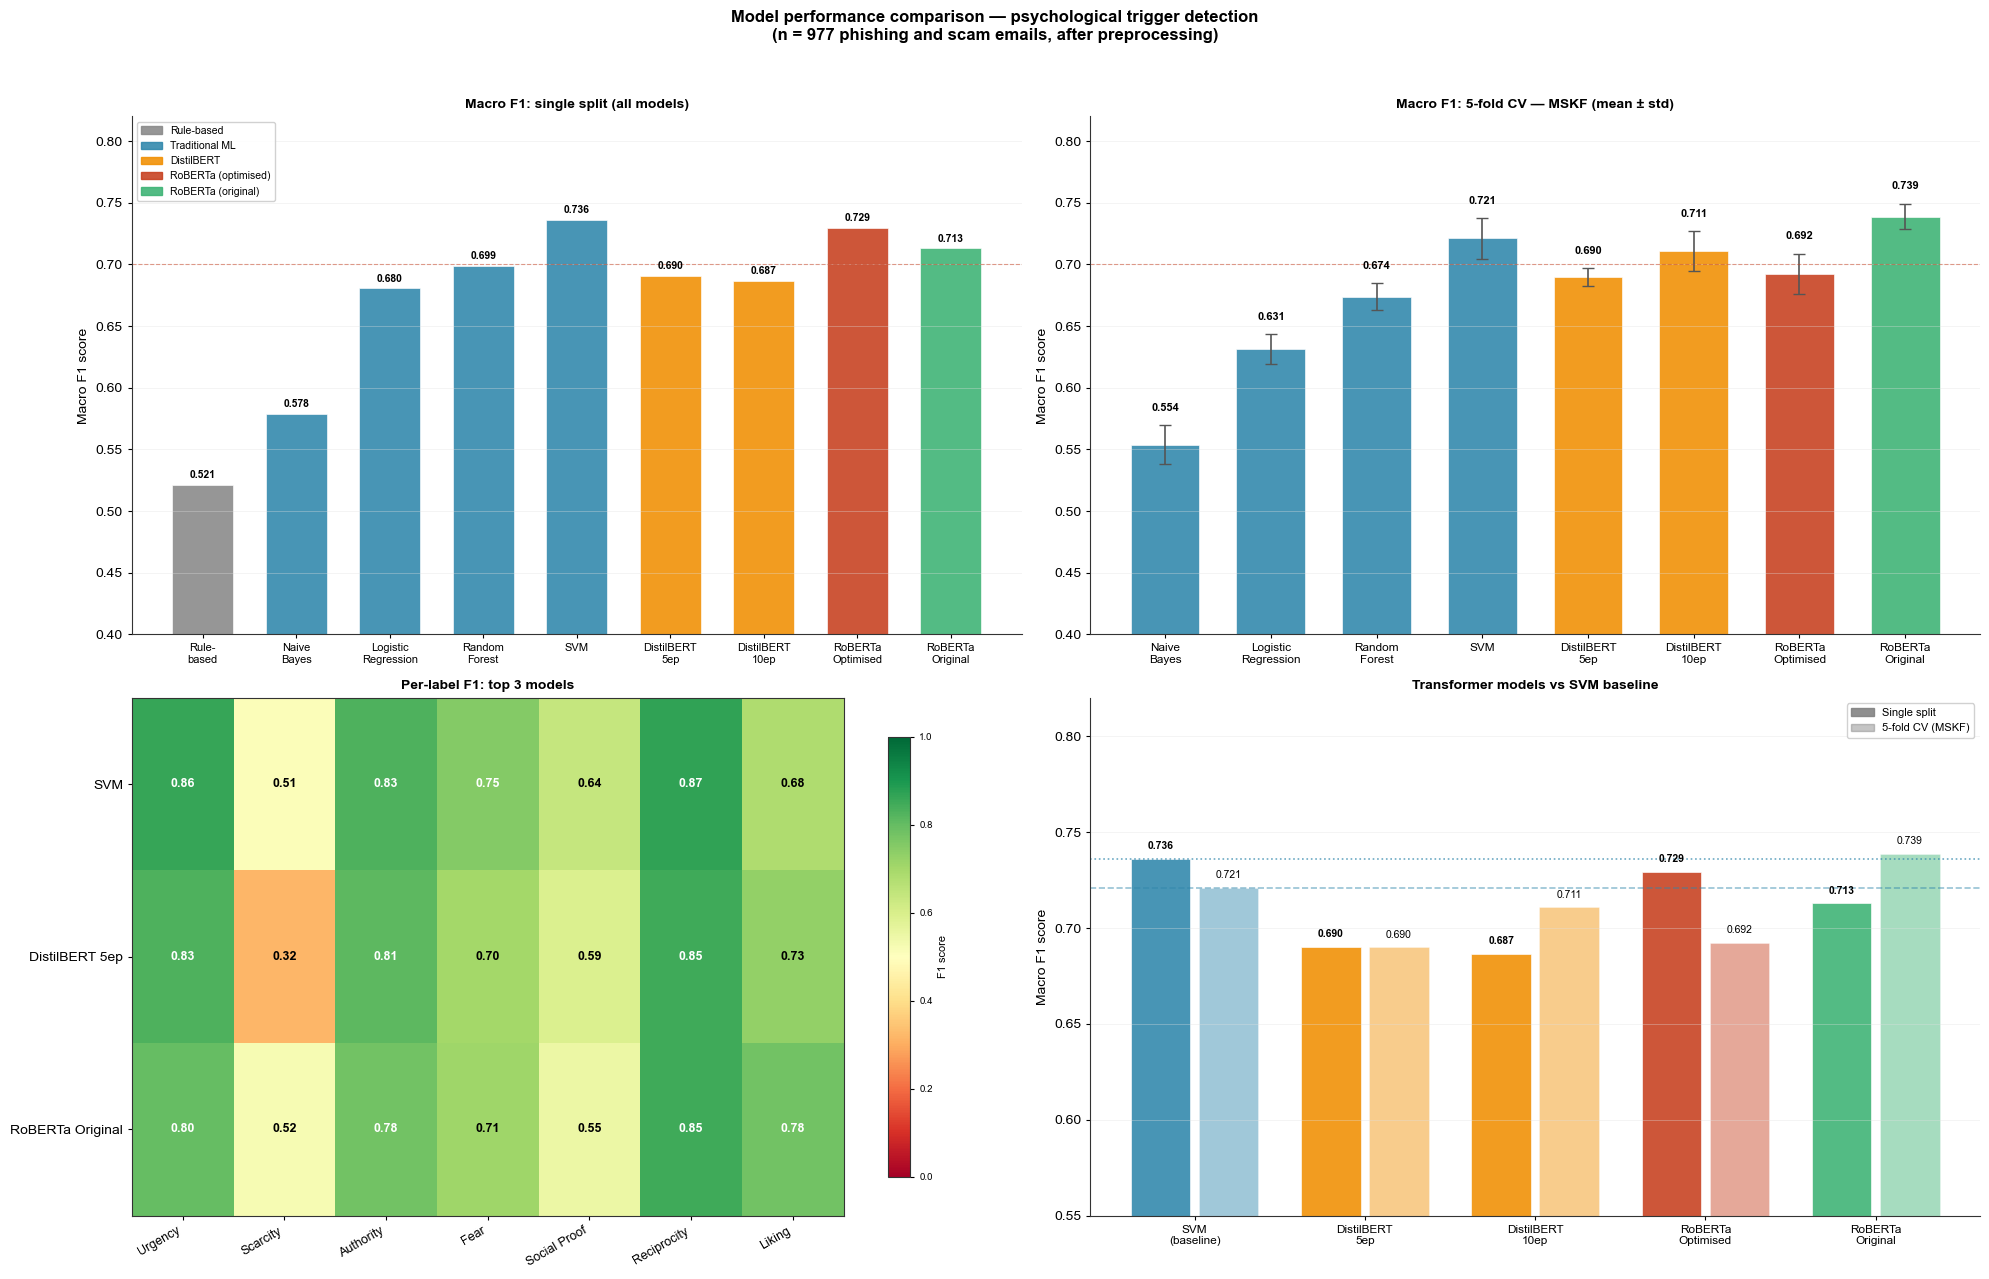

✅ full_model_comparison_final.png


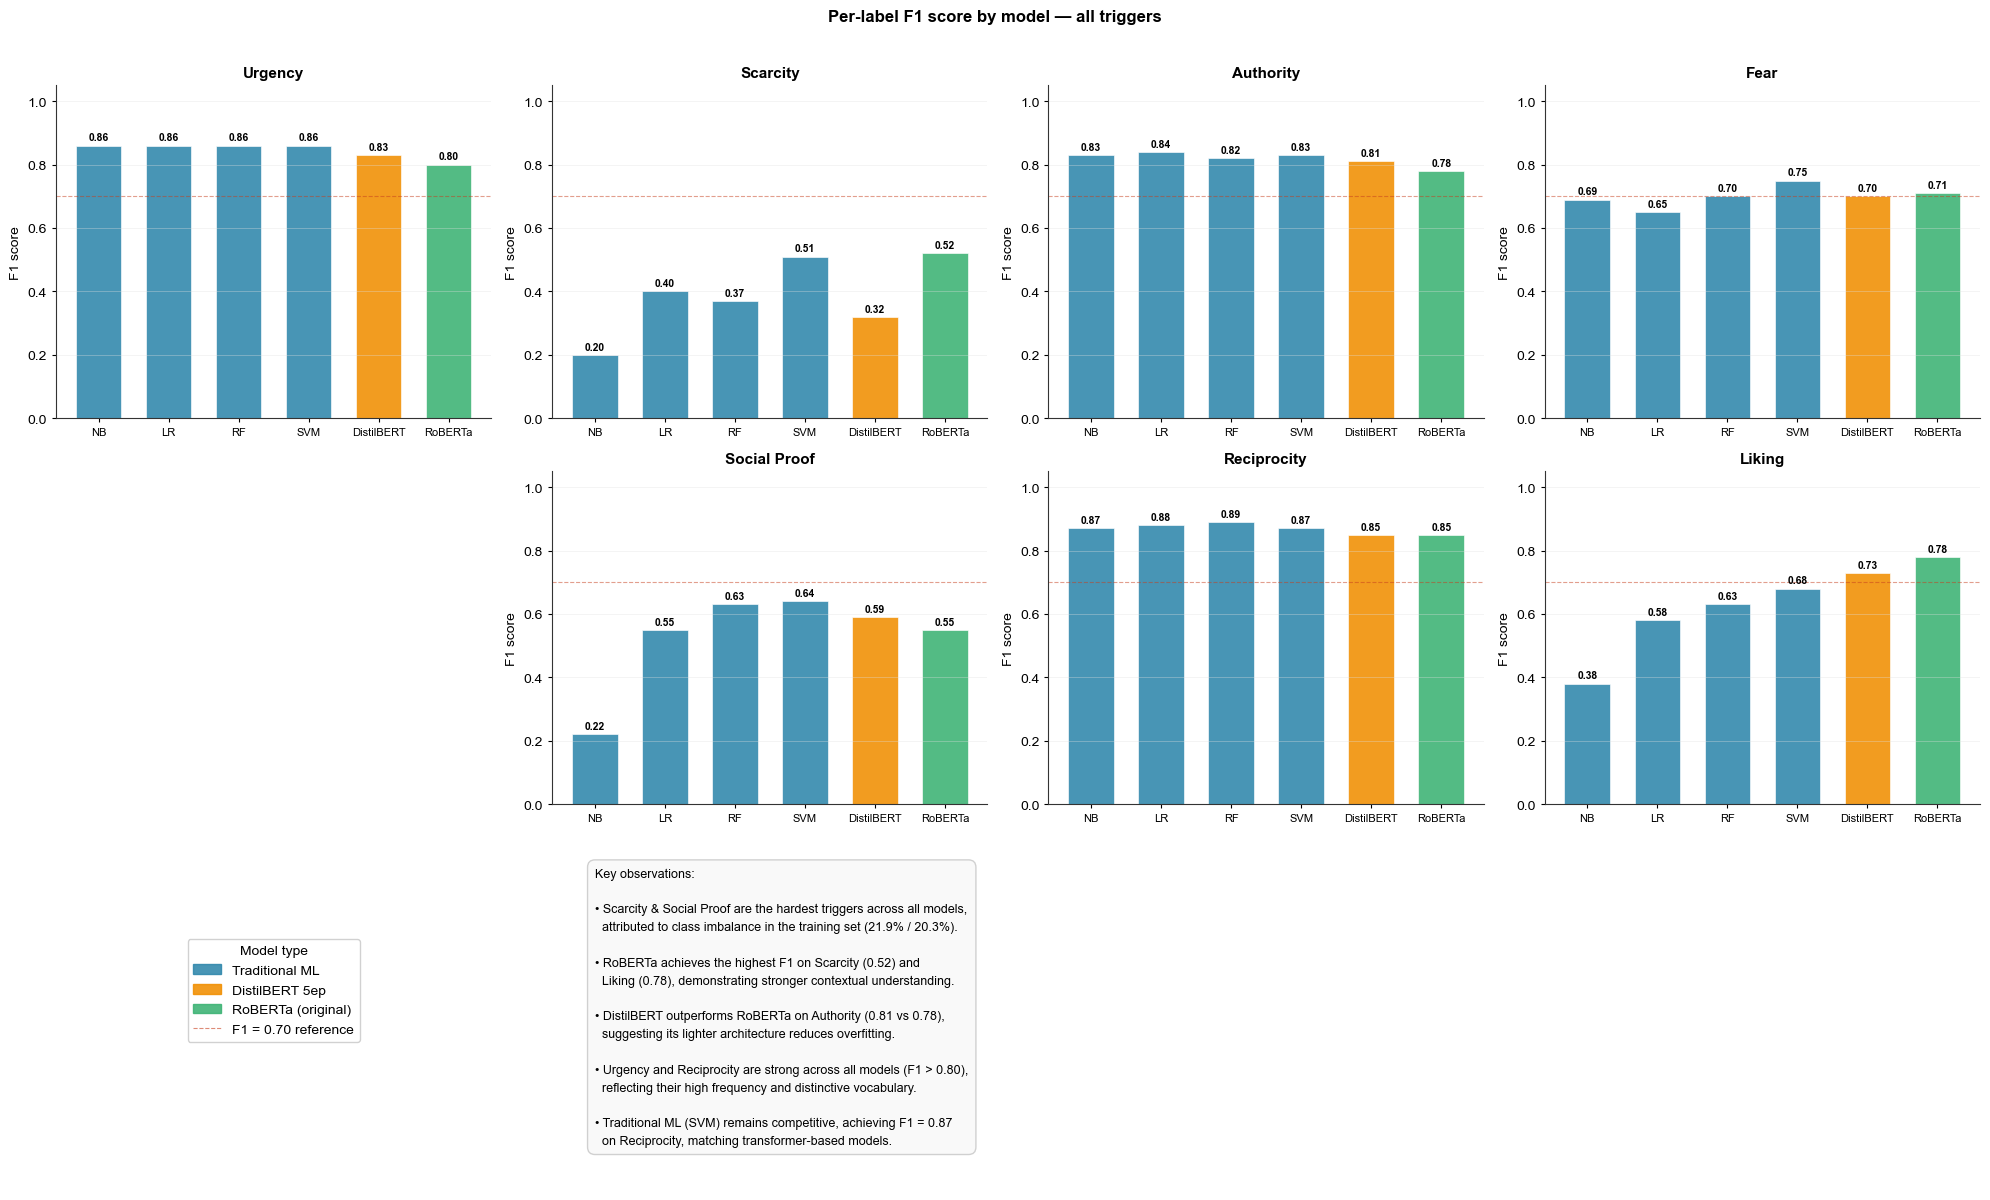

✅ per_label_comparison_final.png


In [24]:
# ============================================================
# Learning Curve — DistilBERT (5ep + 10ep)
# ============================================================
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import torch, torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR
import numpy as np

class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True, max_length=512
        )
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tokenizer_distil = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
train_dataset = EmailDataset(X_train, y_train, tokenizer_distil)
test_dataset  = EmailDataset(X_test,  y_test,  tokenizer_distil)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=16)

criterion = nn.BCEWithLogitsLoss()

# ---- 5 epochs ----
print("🚀 DistilBERT 5ep...\n")
model_d5 = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=7
)
model_d5.to(device)
optimizer = AdamW(model_d5.parameters(), lr=2e-5, weight_decay=0.01)

d5_train_loss, d5_val_loss, d5_val_f1 = [], [], []

for epoch in range(5):
    # Train
    model_d5.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        outputs = model_d5(input_ids=batch['input_ids'].to(device),
                           attention_mask=batch['attention_mask'].to(device))
        loss = criterion(outputs.logits, batch['labels'].to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    d5_train_loss.append(total_loss / len(train_loader))

    # Validation
    model_d5.eval()
    val_loss, preds_all, labels_all = 0, [], []
    with torch.no_grad():
        for batch in test_loader:
            outputs = model_d5(input_ids=batch['input_ids'].to(device),
                               attention_mask=batch['attention_mask'].to(device))
            loss = criterion(outputs.logits, batch['labels'].to(device))
            val_loss += loss.item()
            preds_all.extend((torch.sigmoid(outputs.logits) > 0.5).cpu().numpy())
            labels_all.extend(batch['labels'].numpy())
    d5_val_loss.append(val_loss / len(test_loader))
    d5_val_f1.append(f1_score(labels_all, preds_all, average='macro', zero_division=0))
    print(f"Epoch {epoch+1}/5 — Train Loss: {d5_train_loss[-1]:.4f} | Val Loss: {d5_val_loss[-1]:.4f} | Val F1: {d5_val_f1[-1]:.4f}")

print(f"\n✅ DistilBERT 5ep Final Val F1: {d5_val_f1[-1]:.4f}")
del model_d5
torch.cuda.empty_cache()

# ---- 10 epochs ----
print("\n🚀 DistilBERT 10ep...\n")
model_d10 = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=7
)
model_d10.to(device)

NUM_EPOCHS  = 10
total_steps = len(train_loader) * NUM_EPOCHS
optimizer   = AdamW(model_d10.parameters(), lr=2e-5, weight_decay=0.01)
scheduler   = LinearLR(optimizer, start_factor=1.0, end_factor=0.1,
                       total_iters=total_steps)

d10_train_loss, d10_val_loss, d10_val_f1 = [], [], []

for epoch in range(10):
    model_d10.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        outputs = model_d10(input_ids=batch['input_ids'].to(device),
                            attention_mask=batch['attention_mask'].to(device))
        loss = criterion(outputs.logits, batch['labels'].to(device))
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    d10_train_loss.append(total_loss / len(train_loader))

    model_d10.eval()
    val_loss, preds_all, labels_all = 0, [], []
    with torch.no_grad():
        for batch in test_loader:
            outputs = model_d10(input_ids=batch['input_ids'].to(device),
                                attention_mask=batch['attention_mask'].to(device))
            loss = criterion(outputs.logits, batch['labels'].to(device))
            val_loss += loss.item()
            preds_all.extend((torch.sigmoid(outputs.logits) > 0.5).cpu().numpy())
            labels_all.extend(batch['labels'].numpy())
    d10_val_loss.append(val_loss / len(test_loader))
    d10_val_f1.append(f1_score(labels_all, preds_all, average='macro', zero_division=0))
    print(f"Epoch {epoch+1:02d}/10 — Train Loss: {d10_train_loss[-1]:.4f} | Val Loss: {d10_val_loss[-1]:.4f} | Val F1: {d10_val_f1[-1]:.4f}")

print(f"\n✅ DistilBERT 10ep Final Val F1: {d10_val_f1[-1]:.4f}")
del model_d10
torch.cuda.empty_cache()

# 儲存數據備用
distilbert_curves = {
    'd5_train': d5_train_loss, 'd5_val': d5_val_loss, 'd5_f1': d5_val_f1,
    'd10_train': d10_train_loss, 'd10_val': d10_val_loss, 'd10_f1': d10_val_f1,
}
print("\n✅ DistilBERT curves saved to distilbert_curves")

🚀 DistilBERT 5ep...



Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 3571.66it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/5 — Train Loss: 0.6016 | Val Loss: 0.5325 | Val F1: 0.4791
Epoch 2/5 — Train Loss: 0.4924 | Val Loss: 0.4654 | Val F1: 0.5825
Epoch 3/5 — Train Loss: 0.4225 | Val Loss: 0.4258 | Val F1: 0.6566
Epoch 4/5 — Train Loss: 0.3701 | Val Loss: 0.4065 | Val F1: 0.7189
Epoch 5/5 — Train Loss: 0.3301 | Val Loss: 0.4124 | Val F1: 0.6873

✅ DistilBERT 5ep Final Val F1: 0.6873

🚀 DistilBERT 10ep...



Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 3571.26it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 01/10 — Train Loss: 0.6058 | Val Loss: 0.5320 | Val F1: 0.4953
Epoch 02/10 — Train Loss: 0.4879 | Val Loss: 0.4583 | Val F1: 0.5909
Epoch 03/10 — Train Loss: 0.4248 | Val Loss: 0.4364 | Val F1: 0.6305
Epoch 04/10 — Train Loss: 0.3873 | Val Loss: 0.4175 | Val F1: 0.6802
Epoch 05/10 — Train Loss: 0.3549 | Val Loss: 0.4183 | Val F1: 0.6706
Epoch 06/10 — Train Loss: 0.3244 | Val Loss: 0.4162 | Val F1: 0.6933
Epoch 07/10 — Train Loss: 0.3045 | Val Loss: 0.4158 | Val F1: 0.6902
Epoch 08/10 — Train Loss: 0.2897 | Val Loss: 0.4165 | Val F1: 0.7018
Epoch 09/10 — Train Loss: 0.2746 | Val Loss: 0.4102 | Val F1: 0.6964
Epoch 10/10 — Train Loss: 0.2625 | Val Loss: 0.4173 | Val F1: 0.6950

✅ DistilBERT 10ep Final Val F1: 0.6950

✅ DistilBERT curves saved to distilbert_curves


In [25]:
# ============================================================
# Learning Curve — RoBERTa 5ep
# ============================================================
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import torch, torch.nn as nn
from torch.optim import AdamW
import numpy as np

class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True, max_length=512
        )
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tokenizer_rob = RobertaTokenizer.from_pretrained('roberta-base')
train_dataset = EmailDataset(X_train, y_train, tokenizer_rob)
test_dataset  = EmailDataset(X_test,  y_test,  tokenizer_rob)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=16)

model_rob_lc = RobertaForSequenceClassification.from_pretrained(
    'roberta-base', num_labels=7
)
model_rob_lc.to(device)

optimizer = AdamW(model_rob_lc.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.BCEWithLogitsLoss()

rob_train_loss, rob_val_loss, rob_val_f1 = [], [], []

print("🚀 RoBERTa 5ep Learning Curve...\n")
for epoch in range(5):
    model_rob_lc.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        outputs = model_rob_lc(input_ids=batch['input_ids'].to(device),
                               attention_mask=batch['attention_mask'].to(device))
        loss = criterion(outputs.logits, batch['labels'].to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    rob_train_loss.append(total_loss / len(train_loader))

    model_rob_lc.eval()
    val_loss, preds_all, labels_all = 0, [], []
    with torch.no_grad():
        for batch in test_loader:
            outputs = model_rob_lc(input_ids=batch['input_ids'].to(device),
                                   attention_mask=batch['attention_mask'].to(device))
            loss = criterion(outputs.logits, batch['labels'].to(device))
            val_loss += loss.item()
            preds_all.extend((torch.sigmoid(outputs.logits) > 0.5).cpu().numpy())
            labels_all.extend(batch['labels'].numpy())
    rob_val_loss.append(val_loss / len(test_loader))
    rob_val_f1.append(f1_score(labels_all, preds_all, average='macro', zero_division=0))
    print(f"Epoch {epoch+1}/5 — Train Loss: {rob_train_loss[-1]:.4f} | Val Loss: {rob_val_loss[-1]:.4f} | Val F1: {rob_val_f1[-1]:.4f}")

print(f"\n✅ RoBERTa Final Val F1: {rob_val_f1[-1]:.4f}")

roberta_curves = {
    'train': rob_train_loss,
    'val':   rob_val_loss,
    'f1':    rob_val_f1,
}
print("✅ RoBERTa curves saved to roberta_curves")

del model_rob_lc
torch.cuda.empty_cache()

Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 4633.21it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

🚀 RoBERTa 5ep Learning Curve...

Epoch 1/5 — Train Loss: 0.5807 | Val Loss: 0.4810 | Val F1: 0.5146
Epoch 2/5 — Train Loss: 0.4370 | Val Loss: 0.4239 | Val F1: 0.7103
Epoch 3/5 — Train Loss: 0.3707 | Val Loss: 0.4073 | Val F1: 0.7370
Epoch 4/5 — Train Loss: 0.3300 | Val Loss: 0.4038 | Val F1: 0.6937
Epoch 5/5 — Train Loss: 0.2893 | Val Loss: 0.4084 | Val F1: 0.7347

✅ RoBERTa Final Val F1: 0.7347
✅ RoBERTa curves saved to roberta_curves


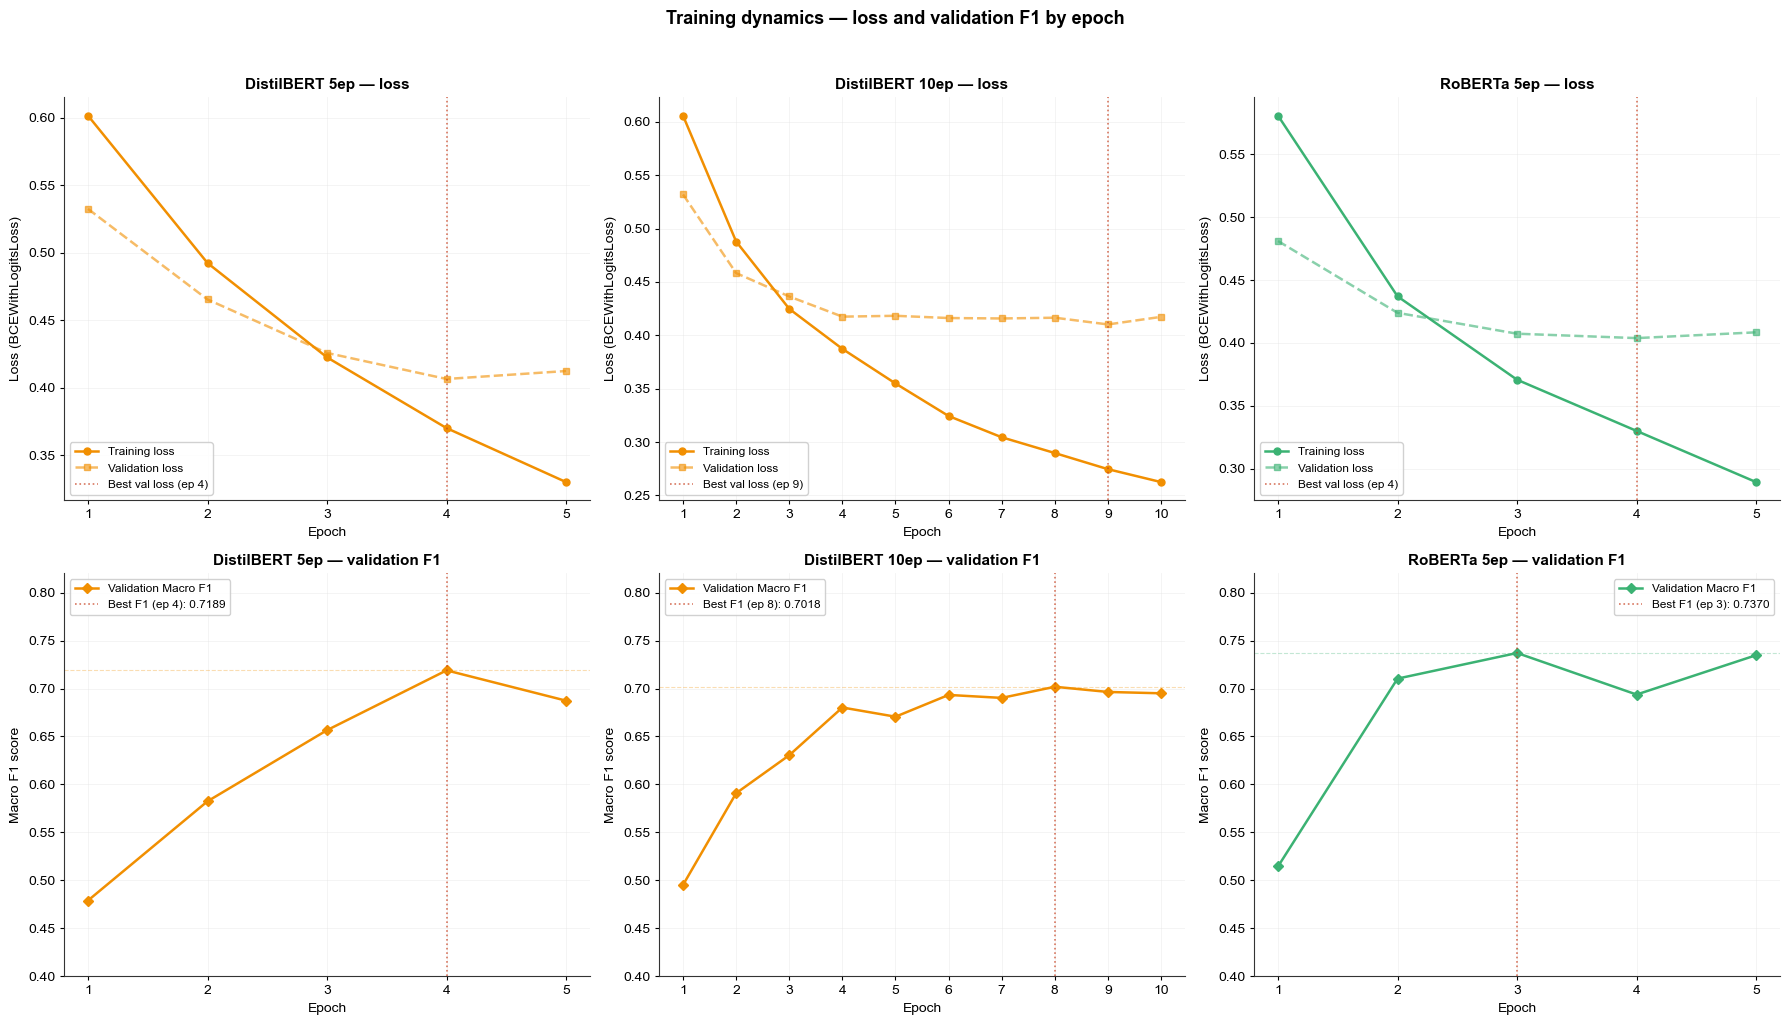

✅ learning_curves_final.png


In [26]:
# ============================================================
# Learning Curve 圖
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family':      'Arial',
    'font.size':        10,
    'axes.linewidth':   0.8,
    'axes.edgecolor':   '#333333',
    'axes.facecolor':   'white',
    'figure.facecolor': 'white',
    'grid.color':       '#E0E0E0',
    'grid.linewidth':   0.6,
})

# 數據
d5_train  = [0.6016, 0.4924, 0.4225, 0.3701, 0.3301]
d5_val    = [0.5325, 0.4654, 0.4258, 0.4065, 0.4124]
d5_f1     = [0.4791, 0.5825, 0.6566, 0.7189, 0.6873]

d10_train = [0.6058, 0.4879, 0.4248, 0.3873, 0.3549,
             0.3244, 0.3045, 0.2897, 0.2746, 0.2625]
d10_val   = [0.5320, 0.4583, 0.4364, 0.4175, 0.4183,
             0.4162, 0.4158, 0.4165, 0.4102, 0.4173]
d10_f1    = [0.4953, 0.5909, 0.6305, 0.6802, 0.6706,
             0.6933, 0.6902, 0.7018, 0.6964, 0.6950]

rob_train = [0.5807, 0.4370, 0.3707, 0.3300, 0.2893]
rob_val   = [0.4810, 0.4239, 0.4073, 0.4038, 0.4084]
rob_f1    = [0.5146, 0.7103, 0.7370, 0.6937, 0.7347]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training dynamics — loss and validation F1 by epoch',
             fontsize=13, fontweight='bold', y=1.02)

def plot_loss(ax, train, val, title, color):
    epochs = range(1, len(train)+1)
    ax.plot(epochs, train, 'o-', color=color, linewidth=1.8,
            markersize=5, label='Training loss')
    ax.plot(epochs, val, 's--', color=color, linewidth=1.8,
            markersize=5, alpha=0.6, label='Validation loss')
    best_ep = val.index(min(val)) + 1
    ax.axvline(x=best_ep, color='#C73E1D', linestyle=':', linewidth=1.2,
               alpha=0.7, label=f'Best val loss (ep {best_ep})')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (BCEWithLogitsLoss)')
    ax.set_xticks(epochs)
    ax.legend(fontsize=8.5, framealpha=0.9)
    ax.grid(alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def plot_f1(ax, f1, title, color):
    epochs = range(1, len(f1)+1)
    ax.plot(epochs, f1, 'D-', color=color, linewidth=1.8,
            markersize=5, label='Validation Macro F1')
    best_ep = f1.index(max(f1)) + 1
    ax.axvline(x=best_ep, color='#C73E1D', linestyle=':', linewidth=1.2,
               alpha=0.7, label=f'Best F1 (ep {best_ep}): {max(f1):.4f}')
    ax.axhline(y=max(f1), color=color, linestyle='--', linewidth=0.8, alpha=0.3)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Macro F1 score')
    ax.set_xticks(epochs)
    ax.set_ylim(0.4, 0.82)
    ax.legend(fontsize=8.5, framealpha=0.9)
    ax.grid(alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Row 1: Loss curves
plot_loss(axes[0][0], d5_train,  d5_val,  'DistilBERT 5ep — loss',  '#F18F01')
plot_loss(axes[0][1], d10_train, d10_val, 'DistilBERT 10ep — loss', '#F18F01')
plot_loss(axes[0][2], rob_train, rob_val, 'RoBERTa 5ep — loss',     '#3BB273')

# Row 2: F1 curves
plot_f1(axes[1][0], d5_f1,  'DistilBERT 5ep — validation F1',  '#F18F01')
plot_f1(axes[1][1], d10_f1, 'DistilBERT 10ep — validation F1', '#F18F01')
plot_f1(axes[1][2], rob_f1, 'RoBERTa 5ep — validation F1',     '#3BB273')

plt.tight_layout()
plt.savefig('learning_curves_final.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ learning_curves_final.png")